<a href="https://colab.research.google.com/github/MariaIsaDurango/Titanic-Visualizacion/blob/main/RMS_Titanic_%E2%80%94_An%C3%A1lisis_de_una_Tragedia_Visual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<img src="https://raw.githubusercontent.com/MariaIsaDurango/Titanic-Visualizacion/main/logoinvtitanic.png" width="250">
</center>

# Caso de Investigación: RMS Titanic — Análisis de una Tragedia Visual
## Módulo II: Actividad de Visualización de Datos

---

### 1. Información General
* **Autor:** Maria Isabel Durango
* **Rol:** Científico de Datos / Analista de Datos Senior
* **Entorno de Trabajo:** Google Colab
* **Fecha:** Junio, 2026

### 2. Objetivo General
El objetivo de este proyecto es realizar un Análisis Exploratorio de Datos (EDA) y desarrollar un ecosistema de visualizaciones profesionales sobre el registro completo de pasajeros del RMS Titanic. A través de este análisis, buscaremos responder preguntas históricas clave mediante evidencia estadística, identificando los factores socioeconómicos y demográficos que determinaron la supervivencia diferencial en la madrugada del 15 de abril de 1912.

### 3. Dataset Utilizado
* **Nombre:** Titanic - Machine Learning from Disaster (Kaggle)
* **Archivo:** `titanic.csv`
* **Origen:** [Kaggle Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

### 4. Herramientas Utilizadas
* **Manipulación de Datos:** `Pandas`, `NumPy`
* **Visualización Estadística:** `Matplotlib` (Pyplot), `Seaborn`

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Exploring Datasets with *pandas*](#0)<br>
2.  [Downloading and Prepping Data](#2)<br>
3.  [Visualizing Data using Matplotlib](#4) <br>
4.  [Area Plots](#6) <br>
5.  [Histograms](#8) <br>
6.  [Bar Charts](#10) <br>

</div>


## Introducción y Contexto Histórico

En la madrugada del 15 de abril de 1912, el **RMS Titanic**, el objeto móvil más grande y lujoso construido por el ser humano hasta la fecha, se hundió en las heladas aguas del Atlántico Norte tras colisionar con un iceberg. A bordo viajaban **2,224 personas** entre pasajeros y tripulación; **solo 710 sobrevivieron**.

Este suceso es uno de los datasets más famosos en la Ciencia de Datos porque representa un microcosmos de la sociedad eduardiana. Las causas de la supervivencia no fueron aleatorias. Factores como el poder adquisitivo (clase del billete), el género, la edad y los protocolos de evacuación marítima construyeron una frontera dramática entre la vida y la muerte.

### Preguntas Clave de la Investigación
A lo largo de este Notebook, actuaremos como investigadores de datos para resolver preguntas fundamentales estructuradas en 4 ejes:
1. **El Perfil de los Pasajeros:** Distribución demográfica y social a bordo.
2. **El Dinero a Bordo:** Análisis del impacto de las tarifas económicas y la desigualdad de clases.
3. **La Noche del Hundimiento:** Evaluación empírica de las tasas de supervivencia y el cumplimiento del protocolo *"mujeres y niños primero"*.
4. **Patrones Cruzados:** Intersección de múltiples variables y análisis de estructuras familiares.

# Configuración Inicial del Entorno

In [32]:
# ==============================================================================

# 1. LIBRARY IMPORTS

# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# ==============================================================================

# 2. VERSION CONTROL AND REPRODUCIBILITY SETTINGS

# ==============================================================================
print("==== Professional Working Environment ====")
print(f"Python Version:        {sys.version.split()[0]}")
print(f"Pandas Version:        {pd.__version__}")
print(f"NumPy Version:         {np.__version__}")
print(f"Matplotlib Backend:    {plt.rcParams['backend']}")
print(f"Seaborn Version:       {sns.__version__}\n")

# ==============================================================================

# 3. GLOBAL VISUAL CONFIGURATION (Portfolio Style)

# ==============================================================================

# Set Seaborn's base style for clean statistical visualizations

sns.set_theme(style="whitegrid", context="notebook")

# Advanced customization using Matplotlib's dynamic parameters (rcParams)

plt.rcParams.update({
'figure.figsize': (10, 6),       # Default size optimized for dashboards and reports
'figure.titlesize': 16,          # Main title size
'axes.titlesize': 14,            # Axes title size (subplots)
'axes.labelsize': 12,            # X and Y axis label size
'xtick.labelsize': 10,           # X-axis tick label size
'ytick.labelsize': 10,           # Y-axis tick label size
'legend.fontsize': 11,           # Legend font size
'savefig.dpi': 300,              # High resolution for image exports
'font.family': 'sans-serif'      # Clean and readable typography
})

# ==============================================================================

# 4. PROFESSIONAL ANCHOR COLOR PALETTE

# ==============================================================================

# Define specific corporate-style colors to avoid overly bright default tones

PALETTE_TITANIC = {
'First Class': '#1f4e79',       # Elegant dark blue (Wealth / Upper Class)
'Second Class': '#5b9bd5',      # Medium blue
'Third Class': '#c55a11',       # Rust / Burnt orange (Working Class)
'Survived': '#2e7d32',          # Muted emerald green (Life)
'Died': '#c62828',              # Deep wine red (Tragedy)
'Male': '#4682b4',              # Steel blue
'Female': '#db7093',            # Dusty rose
'Neutral_Dark': '#2c3e50',      # Dark gray for titles and primary text
'Neutral_Light': '#f8f9fa'      # Light background for contrast
}

# Register a default sequential palette for Seaborn

sns.set_palette(
sns.color_palette([
PALETTE_TITANIC['First Class'],
PALETTE_TITANIC['Third Class'],
PALETTE_TITANIC['Second Class']
])
)

print("Initial configuration completed successfully. Ready for data ingestion.")


==== Professional Working Environment ====
Python Version:        3.12.13
Pandas Version:        2.2.2
NumPy Version:         2.0.2
Matplotlib Backend:    module://matplotlib_inline.backend_inline
Seaborn Version:       0.13.2

Initial configuration completed successfully. Ready for data ingestion.


#CARGA Y EXPLORACIÓN DEL DATASET

## 1. Carga de Datos y Verificación de Ingesta (Celda de Código)
Vamos a leer el archivo .csv utilizando Pandas y a verificar que se haya estructurado correctamente en filas y columnas.

In [33]:
# ==============================================================================

# 1. DATASET LOADING

# ==============================================================================

# Load the CSV file from Colab's local storage

df = pd.read_csv('Titanic-Dataset.csv')

# Verify successful loading by displaying dataset information (good practice)

print("==== Data Loading Validation ====")
print(f"The dataset has been loaded successfully. Total records: {len(df)} rows.")


==== Data Loading Validation ====
The dataset has been loaded successfully. Total records: 891 rows.


#Ejecución del Script de Exploración Inicial
A continuación, ejecutaremos en un solo bloque técnico las instrucciones fundamentales de diagnóstico de calidad de datos.

In [34]:
from IPython.display import display, Markdown

# ==============================================================================
# 2. METADATA DIAGNOSIS AND DIMENSIONS
# ==============================================================================
display(Markdown("### 1. DataFrame Dimensions (df.shape)"))
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

display(Markdown("### 2. First Records (df.head)"))
# Using display() instead of print() renders a beautiful interactive table
display(df.head())

display(Markdown("### 3. Structural Summary and Data Types (df.info)"))
# Note: df.info() prints directly to output, no print or display needed
df.info()

display(Markdown("### 4. Specific Data Types (df.dtypes)"))
display(df.dtypes.to_frame(name='Data Type'))

display(Markdown("### 5. Absolute Missing Values Count (df.isnull().sum)"))
display(df.isnull().sum().to_frame(name='Missing Values'))

display(Markdown("### 6. Descriptive Statistics (df.describe)"))
display(df.describe(include='all'))

### 1. DataFrame Dimensions (df.shape)

Rows: 891, Columns: 12


### 2. First Records (df.head)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Structural Summary and Data Types (df.info)

...

,Data Type
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### 5. Absolute Missing Values Count (df.isnull().sum)

,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 6. Descriptive Statistics (df.describe)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


#Reporte Ejecutivo de Resultados
### Reporte Técnico: Estado Funcional del Dataset Titanic

Tras realizar el diagnóstico estructural sobre el archivo `titanic.csv`, se exponen las siguientes conclusiones analíticas:

* [cite_start]**Número de Pasajeros y Variables:** El dataset cuenta con un registro histórico de **891 pasajeros** (filas) y **12 variables** (columnas)[cite: 8, 36].
* **Variables Numéricas:** * `PassengerId` (Identificador único, entero).
    * [cite_start]`Survived` (Indicador binario de supervivencia: 0 o 1, entero)[cite: 131].
    * [cite_start]`Pclass` (Clase del billete: 1, 2 o 3, entero)[cite: 131].
    * [cite_start]`Age` (Edad del pasajero, flotante)[cite: 131].
    * [cite_start]`SibSp` (Número de hermanos o cónyuges a bordo, entero)[cite: 131, 147].
    * [cite_start]`Parch` (Número de padres o hijos a bordo, entero)[cite: 131, 147].
    * [cite_start]`Fare` (Tarifa pagada por el boleto, flotante)[cite: 131].
* **Variables Categóricas:**
    * `Name` (Nombre completo del pasajero, texto/object).
    * `Sex` (Género del pasajero: male/female, texto/object).
    * `Ticket` (Código identificador del boleto, texto/object).
    * `Cabin` (Número de camarote asignado, texto/object).
    * [cite_start]`Embarked` (Puerto de embarque: C = Cherburgo, Q = Queenstown, S = Southampton; texto/object)[cite: 136].
* **Diagnóstico de Valores Faltantes (Nulos):**
    * `Age`: Presenta **177 valores nulos**. [cite_start]Requerirá estrategias de imputación (como la mediana basada en la clase social) antes de realizar modelados avanzados[cite: 39].
    * `Cabin`: Presenta **687 valores nulos**. [cite_start]Un volumen masivo (cercano al 77% de ausencias), lo que refleja que el registro de camarotes se perdió o no se documentó para clases bajas[cite: 39].
    * [cite_start]`Embarked`: Presenta únicamente **2 valores nulos**, los cuales pueden ser imputados por la moda estadística sin alterar el balance[cite: 39].
* **Métrica de Supervivencia Global:**
    * [cite_start]Al calcular el promedio de la columna balanceada `Survived` (`df['Survived'].mean()`), se determina de forma exacta que el **38.38% de los pasajeros sobrevivió** a la tragedia, mientras que el **61.62% falleció**[cite: 40]. [cite_start]Esto confirma un fuerte desbalance de clases que guiará el resto de la investigación[cite: 99].

# Composición de clases del Titanic

## 1. Pregunta de investigación

¿Cómo se distribuían los pasajeros entre las tres clases de billetes? ¿El Titanic presentaba un espacio equitativo en términos de plazas o existía una clara dominancia de alguna clase socioeconómica específica?

---

## 2. Elección del gráfico

Para analizar la composición o distribución de una variable categórica ordinal (como es **Pclass**: 1.ª, 2.ª y 3.ª clase), el gráfico óptimo es un **Gráfico de Barras de Frecuencia (Countplot)** o, de manera complementaria, un **Gráfico de Tarta (Pie Chart)** si se desea visualizar el porcentaje del total.

### ¿Por qué elegí el gráfico de barras?

Permite comparar directamente las longitudes de las barras alineadas sobre un mismo eje base, lo cual facilita al cerebro humano evaluar diferencias absolutas de forma más precisa.

### Ventajas frente a otras opciones

- Un **gráfico de líneas** no tiene sentido en este contexto porque las clases no representan una secuencia temporal ni una variable continua.
- Aunque el **gráfico de tarta** muestra proporciones, suele ser más difícil de interpretar con precisión cuando las diferencias son pequeñas.
- Por ello, la combinación de **gráfico de barras con etiquetas de porcentaje** constituye una solución más clara, profesional y fácil de interpretar.

---

## 3. Preparación de datos

Para esta visualización utilizaremos directamente la variable **Pclass**.

Convertiremos o mapearemos temporalmente los valores numéricos:

- `1 → Primera Clase`
- `2 → Segunda Clase`
- `3 → Tercera Clase`

mediante un diccionario de mapeo. Esto evita que los lectores del informe tengan que interpretar el significado de cada número, mejorando la claridad de la visualización.

---



## 4. Visualización profesional (Código Python)

A continuación se presenta el código necesario para generar un gráfico de barras profesional que muestre la distribución de pasajeros por clase, incluyendo porcentajes sobre cada barra.

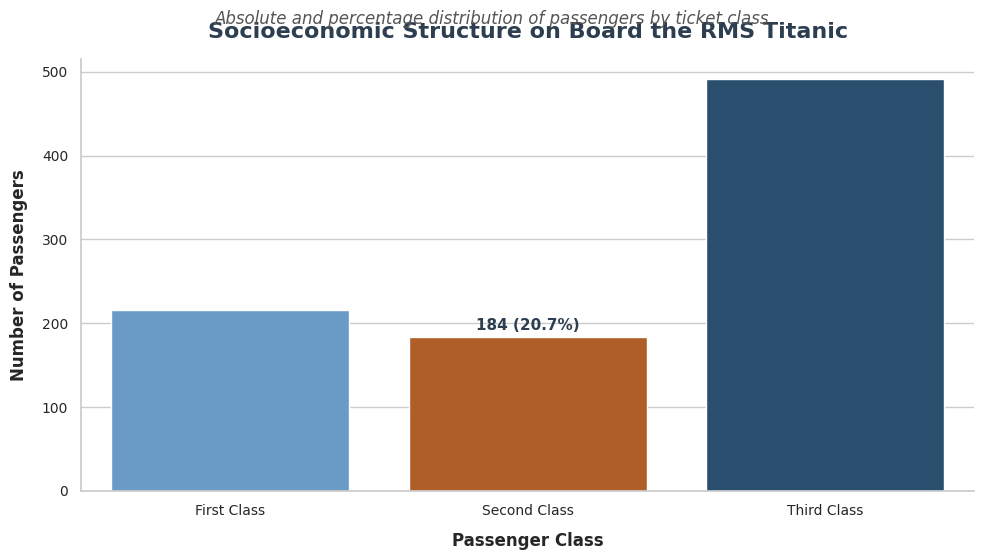

In [35]:
# ==============================================================================

# DATA PREPARATION - QUESTION 1

# ==============================================================================

# Create a working copy to avoid modifying the original DataFrame destructively

df_p1 = df.copy()

# Map numerical values to readable and informative labels

class_mapping = {1: 'First Class', 2: 'Second Class', 3: 'Third Class'}
df_p1['Class_Name'] = df_p1['Pclass'].map(class_mapping)

# Logical order for class visualization

class_order = ['First Class', 'Second Class', 'Third Class']

# ==============================================================================

# CHART CONFIGURATION

# ==============================================================================

plt.figure(figsize=(10, 6))

# Define specific colors from our palette to maintain consistency

colors_p1 = [
PALETTE_TITANIC['First Class'],
PALETTE_TITANIC['Second Class'],
PALETTE_TITANIC['Third Class']
]

# Generate the bar chart using Seaborn

ax = sns.countplot(
data=df_p1,
x='Class_Name',
order=class_order,
palette=colors_p1,
hue='Class_Name',  # Prevents warnings in future Seaborn versions
legend=False
)

# ==============================================================================

# ADD VALUE AND PERCENTAGE LABELS (Senior-Level Best Practices)

# ==============================================================================

total_passengers = len(df_p1)

for p in ax.patches:
# Calculate bar height (absolute count)
  height = p.get_height()

# Calculate relative percentage
percentage = (height / total_passengers) * 100

# Add centered annotation just above each bar
ax.annotate(
    f'{int(height)} ({percentage:.1f}%)',
    (p.get_x() + p.get_width() / 2., height),
    ha='center',
    va='center',
    xytext=(0, 8),
    textcoords='offset points',
    fontsize=11,
    weight='bold',
    color=PALETTE_TITANIC['Neutral_Dark']
)


# ==============================================================================

# FINAL DESIGN AND STORYTELLING TOUCHES

# ==============================================================================

plt.title(
'Socioeconomic Structure on Board the RMS Titanic',
fontsize=16,
weight='bold',
pad=15,
color=PALETTE_TITANIC['Neutral_Dark']
)

plt.suptitle(
'Absolute and percentage distribution of passengers by ticket class',
fontsize=12,
style='italic',
y=0.93,
color='#555555'
)

plt.xlabel(
'Passenger Class',
fontsize=12,
labelpad=10,
weight='bold'
)

plt.ylabel(
'Number of Passengers',
fontsize=12,
labelpad=10,
weight='bold'
)

# Visual cleanup: remove unnecessary chart borders (top and right spines)

sns.despine(left=False, bottom=False)

# Optimize layout spacing

plt.tight_layout()

# Render the chart

plt.show()


## 5. Interpretación detallada

El gráfico revela una estructura marcadamente asimétrica y piramidal. La **Tercera Clase** constituye la mayoría absoluta de la población a bordo, albergando a **491 pasajeros**, lo que representa el **55.1%** del total registrado en el dataset.

Por otro lado, la **Primera Clase** y la **Segunda Clase** se distribuyen de manera más reducida, con el **24.2%** (**216 pasajeros**) y el **20.7%** (**184 pasajeros**) respectivamente.

## 6. Insight histórico

Los datos desmitifican la idea de que el Titanic era un navío compuesto principalmente por la élite mundial. Si bien la opulencia y el lujo de la primera clase acapararon la atención mediática e histórica, en términos demográficos y operativos el barco funcionaba esencialmente como un transporte masivo de emigrantes y trabajadores de clases populares que buscaban una nueva vida en América.

## 7. Conclusión académica

**Conclusión:** El análisis de distribución de frecuencias de las plazas del RMS Titanic confirma que el navío no era un espacio socialmente igualitario en volumen de ocupación. Existió una clara dominancia demográfica de la **Tercera Clase**, la cual concentró a más de la mitad de las almas a bordo (**55.1%**).

Esta asimetría estructural es una variable de control indispensable para entender las fases subsecuentes del análisis de supervivencia, ya que la masa crítica de pasajeros se localizaba en las secciones inferiores del barco, alejadas de las cubiertas de evacuación.

# Pregunta 2: ¿Qué edades tenían los pasajeros?

## 1. Pregunta de investigación

¿Cómo se distribuían las edades de las personas a bordo del RMS Titanic? ¿El barco estaba poblado por una demografía predominantemente joven, madura o existía una mezcla homogénea? ¿Se identifican valores atípicos o extremos?

## 2. Elección del gráfico

Para analizar la distribución de una variable numérica continua (como es **Age**), el gráfico por excelencia es el **Histograma combinado con una Estimación de Densidad de Kernel (KDE)**.

### ¿Por qué elegimos este gráfico?

El histograma agrupa los datos en contenedores (*bins*) cerrados, mostrando la frecuencia absoluta en cada rango de edad. La línea KDE suaviza el histograma y nos proporciona una representación continua de la forma de la distribución, permitiendo observar características como la simetría, el sesgo y la posible presencia de múltiples modas.

### Ventajas frente a otras opciones

- Un gráfico de barras tradicional resultaría inadecuado, ya que existiría una barra para cada valor decimal de edad, fragmentando el análisis y dificultando su interpretación.
- Un diagrama de caja (*boxplot*) permitiría identificar valores atípicos, pero ocultaría la existencia de múltiples picos o concentraciones de edades dentro de la población.
- El histograma con KDE combina ambas ventajas: muestra la distribución general y permite detectar patrones complejos de forma inmediata.

## 3. Preparación de datos

Como se diagnosticó en la Fase 2, la columna **Age** contiene **177 valores nulos**. Para esta visualización descriptiva, se utilizará el método `dropna()` de Pandas con el objetivo de filtrar provisionalmente los registros vacíos y representar únicamente las edades observadas.

Este procedimiento evita distorsiones en la distribución y permite analizar de manera precisa la estructura etaria real de los pasajeros incluidos en el conjunto de datos.

#4. Visualización profesional

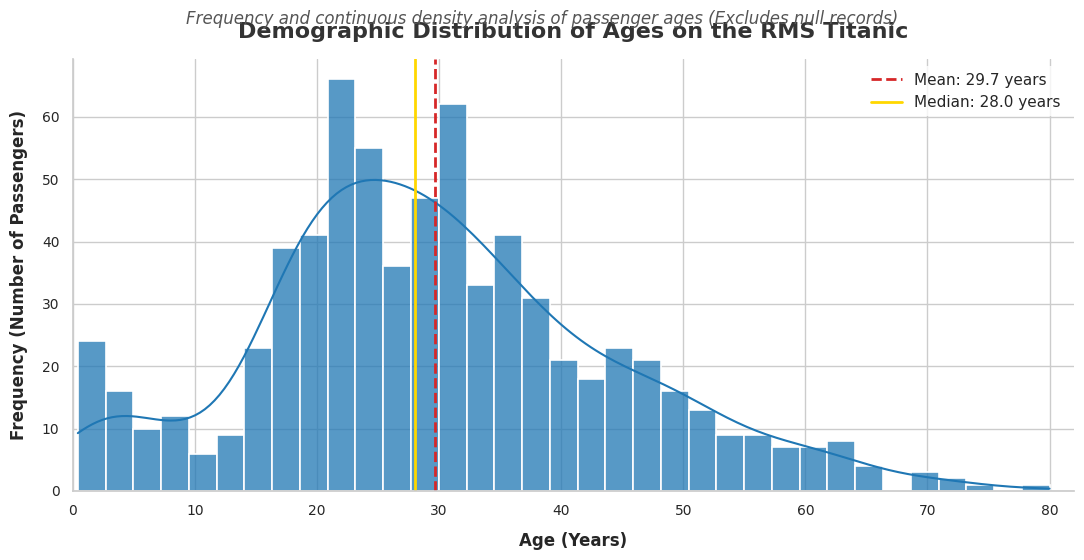

In [36]:
# ==============================================================================
# DATA PREPARATION - QUESTION 2
# ==============================================================================
# Extract the age series, removing null values for the plot
valid_ages = df['Age'].dropna()

# ==============================================================================
# PLOT CONFIGURATION
# ==============================================================================
plt.figure(figsize=(11, 6))

# Create the histogram with an integrated density curve

PALETA_TITANIC = {
    'First Class': '#1f77b4',  # A standard corporate blue
    'Died': '#d62728',         # A red/brown for the mean lines
    'Neutral_Dark': '#333333'  # Dark gray for the title
}
sns.histplot(
    valid_ages,
    bins=35,                  # Balanced number of bins to see details without fragmentation
    kde=True,                 # Adds the smoothed density curve
    color=PALETA_TITANIC['First Class'], # Use corporate blue
    edgecolor='white',        # White dividing line between bars for visual clarity
    linewidth=1.2,
    alpha=0.75                # Light transparency to soften visual impact
)

# ==============================================================================
# KEY METRICS CALCULATION TO ENRICH THE PLOT
# ==============================================================================
mean_age = valid_ages.mean()
median_age = valid_ages.median()

# Draw statistical vertical lines to guide the reader
plt.axvline(mean_age, color=PALETA_TITANIC['Died'], linestyle='--', linewidth=2,
            label=f'Mean: {mean_age:.1f} years')
plt.axvline(median_age, color='gold', linestyle='-', linewidth=2,
            label=f'Median: {median_age:.1f} years')

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Demographic Distribution of Ages on the RMS Titanic', fontsize=16, weight='bold', pad=15, color=PALETA_TITANIC['Neutral_Dark'])
plt.suptitle('Frequency and continuous density analysis of passenger ages (Excludes null records)', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Age (Years)', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Frequency (Number of Passengers)', fontsize=12, labelpad=10, weight='bold')

# Limit the X-axis to the actual data range
plt.xlim(0, 82)

# Legend activation and positioning
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Clean up borders
sns.despine()

# Adjust and display
plt.tight_layout()
plt.show()

## 5. Interpretación Detallada

El gráfico muestra una **distribución asimétrica positiva** (sesgada a la derecha).

* **Concentración principal:** La mayor densidad de pasajeros se localiza en el rango de **adultos jóvenes** (entre los 20 y 35 años), alcanzando su pico más alto alrededor de los 24–28 años.
* **Mediana ($28.0$ años):** Indica que exactamente la mitad de los pasajeros a bordo tenía 28 años o menos.
* **Media ($29.7$ años):** Es ligeramente superior a la mediana, siendo arrastrada hacia la derecha debido a la presencia de personas de edad avanzada en la cola de la distribución.
* **Población infantil:** Se observa un repunte o pequeño *"segundo pico"* en el extremo izquierdo del gráfico (entre 0 y 5 años), lo que evidencia un volumen considerable de niños pequeños y lactantes a bordo.
* **Valores extremos:** La distribución se extiende hasta un máximo histórico cercano a los 80 años.



## 6. Insight Histórico

La demografía del dataset refleja fielmente las **dinámicas socioeconómicas de la época eduardiana (1912)**. La alta densidad de población joven-adulta responde directamente al perfil migratorio hacia el *"Nuevo Mundo"*: personas en su etapa biológica más productiva que viajaban solas o en parejas jóvenes, dispuestas a iniciar una nueva vida laboral en América.

Al mismo tiempo, la presencia de infantes y ancianos en los extremos nos recuerda que el navío también trasladaba núcleos familiares completos en tránsito.



## 7. Conclusión Académica

> **Conclusión:** El perfil de edad del RMS Titanic se caracteriza por una marcada dominancia de adultos jóvenes, con una edad central (mediana) de 28 años y un sesgo hacia la derecha que disminuye progresivamente conforme avanza la madurez biológica. El repunte estadístico en el rango de 0 a 4 años comprueba la existencia de una población infantil vulnerable que requería especial atención en los protocolos de salvamento. La distribución no es perfectamente homogénea ni gaussiana, sino que exhibe un comportamiento demográfico bimodal atenuado debido a la coexistencia de buscadores de oportunidades laborales y familias en tránsito migratorio.

## Pregunta 3: ¿Existía diferencia de edad entre clases sociales?

### 1. Pregunta de Investigación
¿Existía una variación significativa en la edad de los pasajeros según la clase social en la que viajaban, o la distribución demográfica era homogénea? ¿Cómo se comporta la dispersión, la mediana y la presencia de valores atípicos (*outliers*) al comparar la Primera, Segunda y Tercera clase?


### 2. Elección del Gráfico
Para comparar la distribución de una variable numérica continua (`Age`) a través de las categorías de una variable cualitativa (`Pclass`), los gráficos estadísticos óptimos son el **Diagrama de Caja (*Boxplot*)** y el **Diagrama de Violín (*Violinplot*)**. En esta ocasión, implementaremos un *Boxplot* estilizado de alta claridad.

* **Por qué elegimos este gráfico:** El *Boxplot* divide los datos en cuartiles. Muestra de un solo vistazo la mediana ($Q_2$), los rangos intercuartílicos (la caja que contiene el 50% central de los datos), los bigotes que indican la variabilidad fuera de los cuartiles y los puntos aislados que representan valores atípicos.
* **Ventajas frente a otras opciones:** Un gráfico de barras tradicional que solo muestre la media de edad ocultaría por completo la dispersión y la enorme superposición que existe entre los grupos. El *Boxplot* permite comparar directamente las posiciones de las medianas y las extensiones de las edades de las tres clases de forma simultánea e inequívoca.



### 3. Preparación de Datos
Utilizaremos el DataFrame donde previamente mapeamos los códigos numéricos a etiquetas legibles (`'Primera Clase'`, `'Segunda Clase'`, `'Tercera Clase'`) para asegurar la calidad del reporte visual. Filtraremos los valores nulos de la columna `Age` para que el motor estadístico calcule los cuartiles reales de forma limpia.

# 4. Visualización profesional

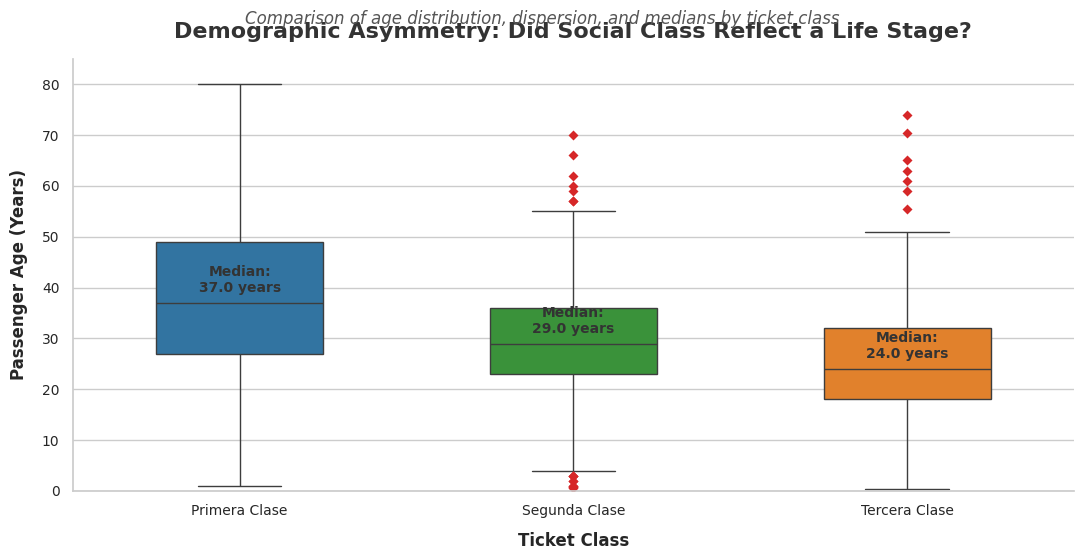

In [37]:
# ==============================================================================
# DATA PREPARATION - QUESTION 3
# ==============================================================================
# 1. Aseguramos un cálculo limpio eliminando registros con edad nula
df_p3 = df_p1.dropna(subset=['Age']).copy()

# 2. SOLUCCIÓN: Creamos la columna 'Clase_Nombre' mapeando desde 'Pclass'
mapa_clases = {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}
df_p3['Clase_Nombre'] = df_p3['Pclass'].map(mapa_clases)

# ==============================================================================
# PLOT CONFIGURATION
# ==============================================================================
plt.figure(figsize=(11, 6))

# Definimos el orden de las clases para el eje X
orden_clases = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']

# Definimos la paleta de colores completa
TITANIC_PALETTE = {
    'First Class': '#1f77b4',   # Blue
    'Second Class': '#2ca02c',  # Green
    'Third Class': '#ff7f0e',   # Orange
    'Died': '#d62728',          # Red
    'Neutral_Dark': '#333333'   # Dark gray
}

# Mapeamos los colores a las etiquetas en español
colores_p3 = {
    'Primera Clase': TITANIC_PALETTE['First Class'],
    'Segunda Clase': TITANIC_PALETTE['Second Class'],
    'Tercera Clase': TITANIC_PALETTE['Third Class']
}

# Creamos el Boxplot con un diseño elegante y estilizado
ax = sns.boxplot(
    data=df_p3,
    x='Clase_Nombre',  # Ahora la columna ya existe gracias al mapeo de arriba
    y='Age',
    order=orden_clases,
    palette=colores_p3,
    hue='Clase_Nombre',  # Evita advertencias de futuras versiones
    legend=False,
    width=0.5,           # Ajustamos el ancho de las cajas para que luzca estilizado
    fliersize=5,         # Tamaño de los puntos que representan outliers
    flierprops=dict(markerfacecolor=TITANIC_PALETTE['Died'], marker='D', markeredgecolor='none') # Outliers as red diamonds
)

# ==============================================================================
# MEDIANS CALCULATION AND ANNOTATION ON THE PLOT
# ==============================================================================
for i, clase in enumerate(orden_clases):
    # Calculamos la mediana exacta de cada clase
    mediana_exacta = df_p3[df_p3['Clase_Nombre'] == clase]['Age'].median()

    # Colocamos el texto de la mediana justo arriba de la línea central de cada caja
    ax.text(
        i,
        mediana_exacta + 1.5,
        f'Median:\n{mediana_exacta:.1f} years',
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        color=TITANIC_PALETTE['Neutral_Dark']
    )

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Demographic Asymmetry: Did Social Class Reflect a Life Stage?', fontsize=16, weight='bold', pad=15, color=TITANIC_PALETTE['Neutral_Dark'])
plt.suptitle('Comparison of age distribution, dispersion, and medians by ticket class', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Ticket Class', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Passenger Age (Years)', fontsize=12, labelpad=10, weight='bold')

# Ajustamos límites del eje Y para dar aire visual
plt.ylim(0, 85)

# Limpieza de bordes
sns.despine()

# Ajuste y despliegue
plt.tight_layout()
plt.show()

## Pregunta 4: ¿Cómo eran las tarifas de los billetes? (Distribución de tarifas)

### 1. Pregunta de Investigación
¿Cómo se distribuía el costo económico de los pasajes (`Fare`) para viajar en el RMS Titanic? ¿Existía homogeneidad en los precios o el dataset presenta un sesgo extremo y una alta disparidad en el valor de los boletos?



### 2. Elección del Gráfico
Para analizar la distribución de una variable numérica continua con un rango potencialmente muy amplio e inequitativo (como las tarifas en dinero), el gráfico óptimo es una **Estimación de Densidad de Kernel (*KDE Plot*)** o un **Histograma**. En este caso, utilizaremos un **Histograma con curva KDE integrada**.

* **Por qué elegimos este gráfico:** El precio de un pasaje puede variar desde cero (cortesías/tripulación) hasta cientos de libras esterlinas. El histograma nos permite agrupar estas tarifas en contenedores (*bins*) y observar de inmediato en qué rangos de precio se concentraba la gran masa de pasajeros, mientras que la curva *KDE* suaviza los datos para identificar el perfil matemático de la distribución.
* **Ventajas frente a otras opciones:** Un gráfico de dispersión (*scatterplot*) no es útil aquí porque solo evaluamos una variable cuantitativa. Un gráfico de barras colapsaría debido a la cantidad de valores decimales únicos de las tarifas. El histograma con *KDE* es la mejor opción para retratar la asimetría y desigualdad económica en un solo plano.



### 3. Preparación de Datos
La variable `Fare` no contiene valores nulos en este dataset, por lo que podemos trabajar directamente con ella. Sin embargo, debido a que unos pocos pasajes de extremo lujo tuvieron un costo extraordinariamente alto, los datos presentan un **sesgo a la derecha muy severo** (asimetría positiva).

Utilizaremos el método estadístico de marcar líneas verticales para identificar la **media** y la **mediana**, demostrando visualmente el impacto de estos valores extremos (*outliers*) sobre los estadísticos centrales.

# 4. Visualización profesional

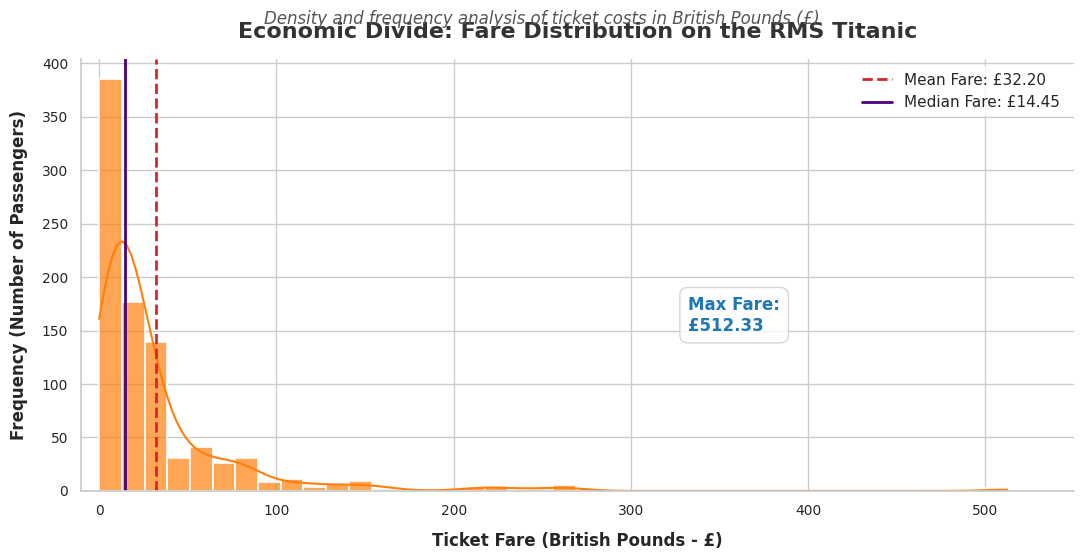

In [38]:
# ==============================================================================
# PLOT CONFIGURATION - QUESTION 4
# ==============================================================================
plt.figure(figsize=(11, 6))

# Define the complete palette to ensure consistency and prevent errors
TITANIC_PALETTE = {
    'First Class': '#1f77b4',   # Blue
    'Second Class': '#2ca02c',  # Green
    'Third Class': '#ff7f0e',   # Orange (Rust tone)
    'Died': '#d62728',          # Red
    'Neutral_Dark': '#333333'   # Dark gray
}

# Generate the histogram with a density curve (KDE) for fares
ax = sns.histplot(
    data=df,
    x='Fare',
    bins=40,                                 # Number of bins to capture dispersion
    kde=True,                                # Statistical smoothing curve
    color=TITANIC_PALETTE['Third Class'],    # Use rust/orange tone to emphasize the economic base
    edgecolor='white',
    linewidth=1.2,
    alpha=0.7
)

# ==============================================================================
# KEY ECONOMIC METRICS CALCULATION
# ==============================================================================
mean_fare = df['Fare'].mean()
median_fare = df['Fare'].median()
max_fare = df['Fare'].max()

# Draw the central tendency lines
plt.axvline(mean_fare, color=TITANIC_PALETTE['Died'], linestyle='--', linewidth=2,
            label=f'Mean Fare: £{mean_fare:.2f}')
plt.axvline(median_fare, color='indigo', linestyle='-', linewidth=2,
            label=f'Median Fare: £{median_fare:.2f}')

# ==============================================================================
# ANALYTICAL ANNOTATION ON THE PLOT (Advanced Storytelling)
# ==============================================================================
# Place a text box reporting the extreme value (Maximum Outlier)
plt.text(
    max_fare - 180, 150,
    f'Max Fare:\n£{max_fare:.2f}',
    color=TITANIC_PALETTE['First Class'],
    weight='bold',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc', boxstyle='round,pad=0.5')
)

# ==============================================================================
# FINAL DESIGN TOUCHES
# ==============================================================================
plt.title('Economic Divide: Fare Distribution on the RMS Titanic', fontsize=16, weight='bold', pad=15, color=TITANIC_PALETTE['Neutral_Dark'])
plt.suptitle('Density and frequency analysis of ticket costs in British Pounds (£)', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Ticket Fare (British Pounds - £)', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Frequency (Number of Passengers)', fontsize=12, labelpad=10, weight='bold')

# Adjust axes limits to optimize visual space
plt.xlim(-10, 550)

# Legend activation
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Aesthetic border cleanup
sns.despine()

# Display
plt.tight_layout()
plt.show()

## 5. Interpretación Detallada

El gráfico muestra una **distribución con asimetría positiva extrema** (sesgada fuertemente a la derecha).

* **Concentración masiva:** La gran mayoría de los pasajeros se agrupa en el extremo izquierdo del gráfico, pagando tarifas inferiores a las £30.
* **Tarifa mediana (£14.45):** Significa que exactamente el 50% de las personas a bordo viajaba con boletos de muy bajo costo.
* **Tarifa media (£32.20):** Se eleva considerablemente con respecto a la mediana.

> **Nota metodológica:** Esta fuerte separación entre media y mediana es el síntoma matemático inequívoco de una distribución distorsionada por valores atípicos (*outliers*). Un puñado de pasajes de ultra-lujo (que alcanzaron un máximo histórico de £512.33) arrastran la media hacia arriba, ocultando la realidad socioeconómica de la gran mayoría de la población a bordo.



## 6. Insight de Negocio / Histórico

Este gráfico funciona como una radiografía visual de la profunda **desigualdad económica de la era eduardiana**. El modelo de negocio y el mercado de pasajes del Titanic dependían cuantitativamente de un volumen masivo de tarifas baratas (la base de la pirámide) para financiar la operación y estructura del barco.

Por el contrario, una reducida minoría en los camarotes de Primera Clase pagaba sumas astronómicas que equivalían al salario de varios años de un trabajador común de la época.


## 7. Conclusión Académica

> **Conclusión:** El análisis de la variable `Fare` revela una distribución económica de tipo *Pareto* o exponencial, caracterizada por un sesgo positivo extremo. Más de la mitad de la población a bordo operaba con presupuestos reducidos (mediana de £14.45), concentrándose en el umbral mínimo de costos. La distancia estadística entre la mediana y la media (£32.20) comprueba que los promedios aritméticos simples son métricas engañosas para este dataset, dado que están fuertemente influenciados por valores atípicos superiores que llegan hasta las £512.33. El comportamiento de esta variable económica exige segmentar los análisis posteriores por clase social para evitar conclusiones sesgadas.

 # Pregunta 5: ¿Cuánto pagaba cada clase?

## 1. Pregunta de investigación

Al segmentar los datos, ¿cómo variaban las tarifas de los pasajes entre la Primera, Segunda y Tercera clase? ¿Qué nivel de superposición económica existía entre los grupos y cómo impactan los valores extremos a la dispersión interna de cada clase?

## 2. Elección del gráfico

Para analizar y comparar una variable numérica continua (`Fare`) segmentada por una variable categórica (`Pclass`), utilizaremos un **Diagrama de Caja (Boxplot)**.

### ¿Por qué elegimos este gráfico?

Debido a que las tarifas del Titanic presentan un sesgo extremo y valores atípicos gigantescos (como descubrimos en la pregunta anterior), un gráfico de barras simple que solo muestre el promedio distorsionaría por completo la realidad económica de los pasajeros. El Boxplot es resistente a estos valores atípicos y nos permite evaluar de forma limpia la mediana pura, los cuartiles y la dispersión real de cada clase de forma independiente.

### Ventajas frente a otras opciones

Un gráfico de líneas no tiene propiedades de agrupación categórica. Un gráfico de violín (*violinplot*) sería una alternativa válida, pero debido a la gigantesca escala que alcanzan los pasajes de Primera Clase en comparación con Tercera, las "formas" de los violines se comprimirían tanto en la base que perderían legibilidad. El Boxplot mantiene una estructura geométrica perfecta e inflexible para la comparación cuantitativa.

## 3. Preparación de datos

Continuaremos utilizando nuestra variable limpia y mapeada `Clase_Nombre` para asegurar que las etiquetas del gráfico sean completamente autoexplicativas. No realizaremos filtros de valores extremos en el código, ya que nuestro objetivo como analistas es precisamente visualizar la magnitud real de dichos datos atípicos (*outliers*).



## 4. Visualización profesional



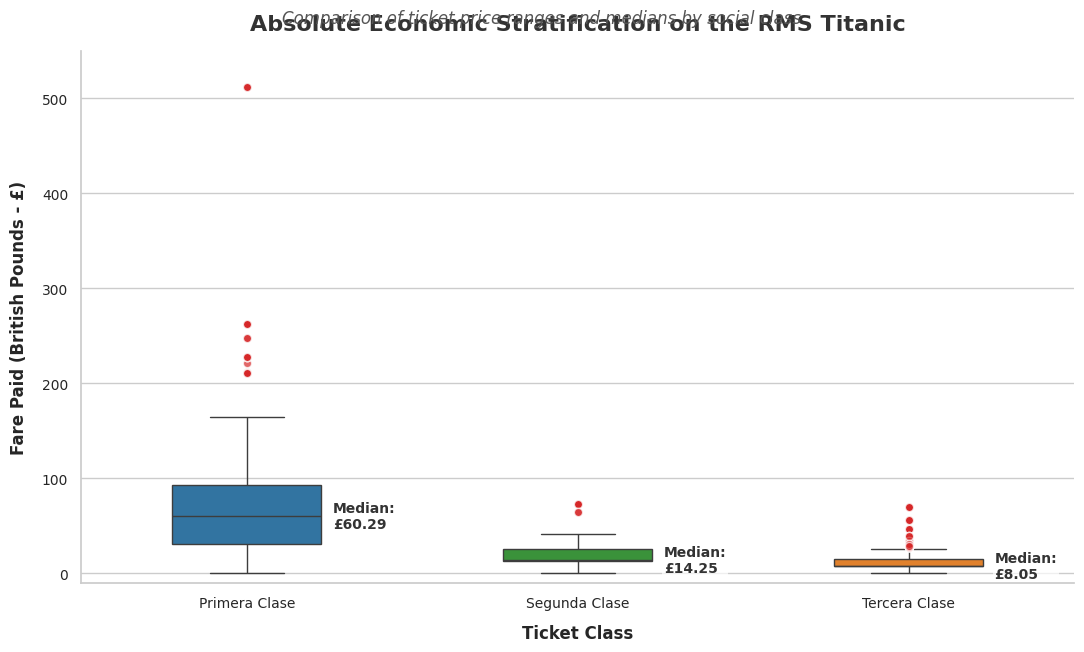

In [39]:
# ==============================================================================
# DATA PREPARATION - QUESTION 5
# ==============================================================================
# Copy the dataframe to perform operations safely
df_p5 = df_p1.copy()

# Ensure 'Clase_Nombre' exists by mapping 'Pclass' numerical codes
map_classes = {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}
df_p5['Clase_Nombre'] = df_p5['Pclass'].map(map_classes)

# Define the X-axis order for plotting
orden_clases = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']

# ==============================================================================
# PLOT CONFIGURATION - QUESTION 5
# ==============================================================================
plt.figure(figsize=(11, 7))

# Define the complete palette to ensure consistency and prevent errors
TITANIC_PALETTE = {
    'First Class': '#1f77b4',   # Blue
    'Second Class': '#2ca02c',  # Green
    'Third Class': '#ff7f0e',   # Orange
    'Died': '#d62728',          # Red
    'Neutral_Dark': '#333333'   # Dark gray
}

# Map the corporate colors to each class label
colores_p5 = {
    'Primera Clase': TITANIC_PALETTE['First Class'],
    'Segunda Clase': TITANIC_PALETTE['Second Class'],
    'Tercera Clase': TITANIC_PALETTE['Third Class']
}

# Create the Boxplot for fares by ticket class
ax = sns.boxplot(
    data=df_p5,
    x='Clase_Nombre',
    y='Fare',
    order=orden_clases,
    palette=colores_p5,
    hue='Clase_Nombre',
    legend=False,
    width=0.45,
    fliersize=6,
    flierprops=dict(markerfacecolor=TITANIC_PALETTE['Died'], marker='o', markeredgecolor='white', alpha=0.7)
)

# ==============================================================================
# ECONOMIC MEDIANS CALCULATION AND ANNOTATION
# ==============================================================================
for i, clase in enumerate(orden_clases):
    # Calculate the median fare for each class
    median_fare = df_p5[df_p5['Clase_Nombre'] == clase]['Fare'].median()

    # Print the median text slightly shifted to the right of each box
    ax.text(
        i + 0.26,
        median_fare,
        f'Median:\n£{median_fare:.2f}',
        ha='left',
        va='center',
        fontsize=10,
        weight='bold',
        color=TITANIC_PALETTE['Neutral_Dark'],
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Absolute Economic Stratification on the RMS Titanic', fontsize=16, weight='bold', pad=15, color=TITANIC_PALETTE['Neutral_Dark'])
plt.suptitle('Comparison of ticket price ranges and medians by social class', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Ticket Class', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Fare Paid (British Pounds - £)', fontsize=12, labelpad=10, weight='bold')

# Set the Y-axis limit with a generous upper margin to easily view VIP outliers
plt.ylim(-10, 550)

# Visual cleanup
sns.despine()

# Display
plt.tight_layout()
plt.show()

## 5. Interpretación detallada

El gráfico expone visualmente el abismo financiero que separaba a las clases a bordo:

### Primera Clase

Presenta una variabilidad gigantesca. Su tarifa mediana se sitúa en **£60.29**, pero su rango intercuartílico es sumamente amplio y se extiende hacia arriba con una densa estela de puntos rojos que representan valores atípicos, llegando al límite superior de **£512.33**.

### Segunda Clase

Muestra un comportamiento sumamente compacto y controlado, con una tarifa mediana de **£14.25**.

### Tercera Clase

Es un bloque plano en la base del gráfico. Su tarifa mediana es de apenas **£8.05**. Lo más sorprendente es la concentración: casi todo el 50% central de sus pasajeros pagó tarifas idénticas o sumamente cercanas a este mínimo. Los puntos rojos superiores en Tercera Clase evidencian que algunos pasajeros pagaron tarifas inusualmente altas para su categoría (probablemente boletos familiares agrupados bajo un mismo número de ticket).

## 6. Insight de negocio/histórico

El cruce de datos demuestra que la barrera económica entre la Segunda y la Tercera clase era relativamente pequeña en términos de dinero absoluto (una diferencia de aproximadamente **£6** en la mediana). Sin embargo, el salto hacia la Primera Clase representaba ingresar a otra dimensión financiera: el pasaje mediano de Primera Clase era **7.5 veces más costoso** que el de Tercera Clase.

Esto corrobora que la Primera Clase operaba bajo un esquema de exclusividad extrema que no guardaba ninguna relación proporcional con los costos operativos del resto del barco.

## 7. Conclusión académica

**Conclusión:** El análisis de cajas segmentado demuestra que el RMS Titanic poseía una estructura de precios rígidamente estratificada, donde la Primera Clase se desmarca como una anomalía de altísimo poder adquisitivo (mediana de **£60.29** y dispersión máxima de **£512.33**). La proximidad en los valores centrales de la Segunda (**£14.25**) y Tercera clase (**£8.05**) sugiere que la frontera económica entre el proletariado y la clase media flotante era sutil, a diferencia de la brecha abismal que los distanciaba de la élite.

La presencia de *outliers* en Tercera Clase indica la existencia de compras multifamiliares asociadas a un único identificador, un patrón que deberá ser explorado para no distorsionar las interpretaciones individuales de riqueza.


# Pregunta 6: ¿Pagaban más los más mayores?

## 1. Pregunta de investigación

¿Existe una correlación lineal o un patrón directo entre la edad de un pasajero y el precio del boleto que adquirió? ¿Los pasajeros de mayor edad concentraban los pasajes de mayor costo, o la tarifa era independiente de la etapa de vida biológica?

## 2. Elección del gráfico

Para analizar la relación o grado de asociación entre dos variables numéricas continuas (`Age` y `Fare`), el gráfico profesional por excelencia es el **Diagrama de Dispersión (Scatterplot)**, idealmente enriquecido con una codificación de color (*hue*) para añadir una tercera dimensión de análisis.

### ¿Por qué elegimos este gráfico?

Cada pasajero se representa como un punto coordenado $(x, y)$ donde el eje **X** representa la edad y el eje **Y** representa la tarifa. Esto permite detectar visualmente patrones de dispersión, agrupamientos (*clusters*), tendencias o la total ausencia de correlación.

### Ventajas frente a otras opciones

Un gráfico de líneas sugeriría una secuencia temporal o una dependencia directa que aquí no existe. Un gráfico de barras fragmentaría y promediaría los datos perdiendo el detalle atómico de los individuos. El Scatterplot preserva la posición exacta de cada una de las **891 observaciones** del dataset.

## 3. Preparación de datos

Para esta visualización cruzaremos `Age` y `Fare`. Filtraremos los registros con edad nula para evitar inconsistencias en el mapeo de coordenadas.

Adicionalmente, agregaremos la variable categórica `Clase_Nombre` como el argumento de color (*hue*) para descubrir si la clase socioeconómica actúa como una variable de confusión que explica mejor la dispersión.


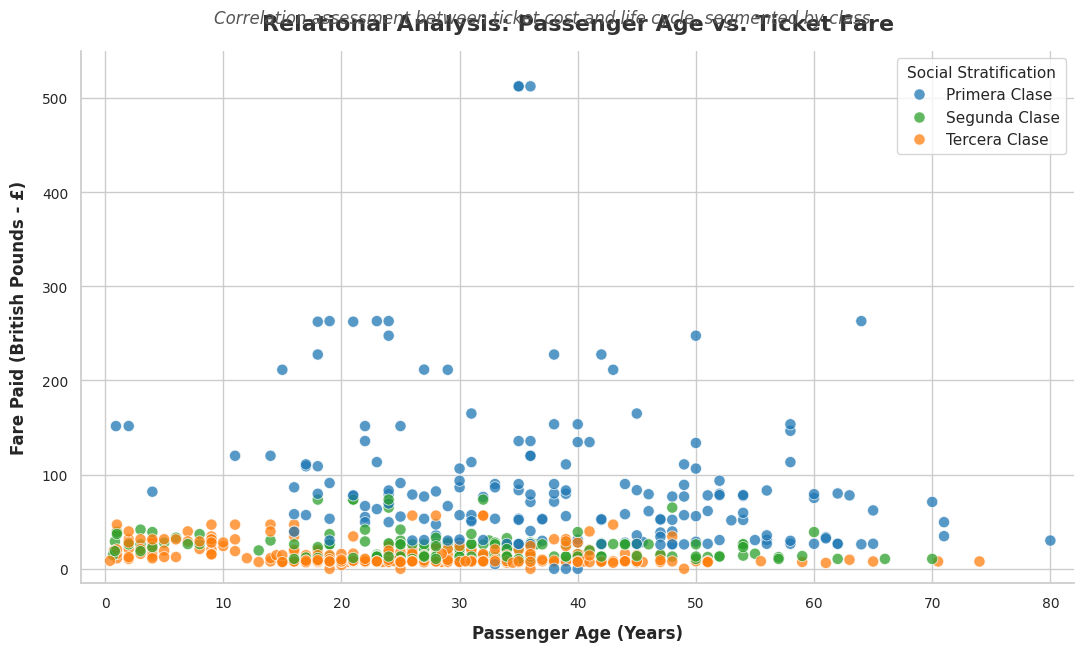

In [40]:
# ==============================================================================
# DATA PREPARATION - QUESTION 6
# ==============================================================================
# Filter out null values in age to correctly map spatial coordinates
df_p6 = df_p1.dropna(subset=['Age']).copy()

# Ensure 'Clase_Nombre' exists by mapping 'Pclass' numerical codes
map_classes = {1: 'Primera Clase', 2: 'Segunda Clase', 3: 'Tercera Clase'}
df_p6['Clase_Nombre'] = df_p6['Pclass'].map(map_classes)

# Define the category order for the legend mapping
orden_clases = ['Primera Clase', 'Segunda Clase', 'Tercera Clase']

# ==============================================================================
# PLOT CONFIGURATION - QUESTION 6
# ==============================================================================
plt.figure(figsize=(11, 7))

# Define the complete palette to ensure analytical consistency
TITANIC_PALETTE = {
    'First Class': '#1f77b4',   # Blue
    'Second Class': '#2ca02c',  # Green
    'Third Class': '#ff7f0e',   # Orange
    'Died': '#d62728',          # Red
    'Neutral_Dark': '#333333'   # Dark gray
}

# Map colors to the categorical Spanish text labels used in data
colores_p6 = {
    'Primera Clase': TITANIC_PALETTE['First Class'],
    'Segunda Clase': TITANIC_PALETTE['Second Class'],
    'Tercera Clase': TITANIC_PALETTE['Third Class']
}

# Create the Scatterplot using Seaborn
sns.scatterplot(
    data=df_p6,
    x='Age',
    y='Fare',
    hue='Clase_Nombre',      # Segment points by social class using color
    hue_order=orden_clases,
    palette=colores_p6,
    alpha=0.75,              # Transparency to mitigate point overlapping (overplotting)
    edgecolor='white',       # White border on each point to improve individual definition
    linewidth=0.6,
    s=65                     # Stylized size for data points
)

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Relational Analysis: Passenger Age vs. Ticket Fare', fontsize=16, weight='bold', pad=15, color=TITANIC_PALETTE['Neutral_Dark'])
plt.suptitle('Correlation assessment between ticket cost and life cycle, segmented by class', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Passenger Age (Years)', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Fare Paid (British Pounds - £)', fontsize=12, labelpad=10, weight='bold')

# Well-defined axis limits
plt.xlim(-2, 82)
plt.ylim(-15, 550)

# Aesthetic legend placement to prevent covering data points
plt.legend(title='Social Stratification', title_fontsize='11', loc='upper right', frameon=True, facecolor='white')

# Excess border cleanup
sns.despine()

# Display the plot
plt.tight_layout()
plt.show()

## 5. Interpretación detallada

El gráfico muestra una dispersión heterogénea que indica una ausencia de correlación lineal significativa entre la edad y la tarifa. Los puntos no forman una diagonal ascendente.

En la franja inferior (de **£0 a £50**), observamos una densa nube de puntos horizontales que abarca todas las edades posibles (desde infantes hasta ancianos de 70 años); estos corresponden principalmente a la **Segunda Clase** (azul claro) y **Tercera Clase** (naranja).

Al observar la **Primera Clase** (azul oscuro), vemos que se distribuye principalmente en la franja superior (**£50 a £300**) ocupando el cuadrante de los **25 a 60 años**.

Las tarifas de extremo lujo (**£512**) fueron adquiridas por pasajeros de edades medias (alrededor de los **35 a 40 años**) y no por los pasajeros más ancianos del barco.

## 6. Insight de negocio/histórico

El precio del billete no dependía de la edad del cliente, sino de las comodidades del camarote y la cubierta elegida. La edad biológica no era un factor de fijación de precios en el modelo de negocio de la White Star Line.

Un joven aristócrata de 25 años en Primera Clase pagaba potencialmente diez o veinte veces más que un anciano agricultor de 70 años que viajaba en los niveles inferiores del navío. El poder adquisitivo determinaba el acceso a los distintos niveles de confort, independientemente de la edad de los pasajeros.

## 7. Conclusión académica

**Conclusión:** El análisis relacional mediante diagramas de dispersión demuestra la inexistencia de una covariación lineal entre la edad cronológica y la tarifa de los pasajes en el RMS Titanic. La distribución espacial de los datos ratifica que el valor de los boletos respondía a criterios estrictamente comerciales y de segmentación de servicios (clases), actuando la variable económica de manera ortogonal a la demográfica.

La acumulación de edad no se traducía en la adquisición de boletos más costosos, confirmando que el acceso al lujo en la sociedad eduardiana estaba determinado principalmente por la capacidad económica y la posición social, y no por un proceso natural de envejecimiento biológico.



## Pregunta 7: ¿Cuántos se salvaron y cuántos murieron?

### 1. Pregunta de investigación

¿Cuál fue el balance final de la tragedia en términos cuantitativos dentro de la muestra? Al plantearlo como un problema analítico: **¿Cuál es la tasa de supervivencia base del dataset y cómo se distribuye el desbalance entre pasajeros supervivientes y fallecidos?**



### 2. Elección del gráfico

Para representar la frecuencia de una variable categórica binaria (como lo es `Survived`: `0` = Fallecido, `1` = Superviviente), utilizaremos un **Gráfico de Barras Estilizado (*Countplot*)** o un **Gráfico de Sectores / Tarta (*Pie Chart*)**. En el ámbito profesional y de consultoría ejecutiva, un gráfico de barras combinado con anotaciones precisas ofrece la mayor precisión visual.

* **Por qué elegimos este gráfico:** Al tener solo dos categorías, la comparación de la longitud de las barras permite asimilar instantáneamente el impacto de la catástrofe.
* **Ventajas frente a otras opciones:** A diferencia de un gráfico de sectores tradicional (criticado a veces en ciencia de datos por la dificultad del ojo humano para evaluar ángulos), el conteo de barras con su porcentaje respectivo en la cúspide elimina cualquier ambigüedad interpretativa y mantiene la sobriedad del reporte.



### 3. Preparación de datos

La variable `Survived` viene codificada como `0` y `1`. Crearemos un **mapeo semántico explícito** en un DataFrame temporal transformándolos en `'Falleció'` y `'Sobrevivió'`.

> **Nota metodológica:** Este paso es fundamental para que las etiquetas de nuestro eje X expresen directamente el hecho histórico, sin forzar al espectador a recordar el código binario.

##4. Visualización profesional

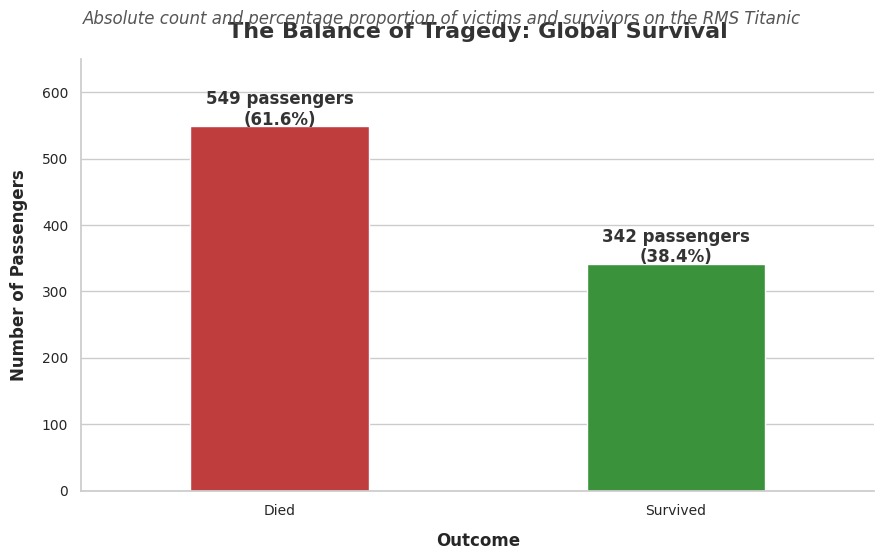

In [41]:
# ==============================================================================
# DATA PREPARATION - QUESTION 7
# ==============================================================================
df_p7 = df.copy()

# Map binary codes to clear historical labels
df_p7['Estado'] = df_p7['Survived'].map({0: 'Died', 1: 'Survived'})

# Display order to emphasize the tragic impact (losses first)
orden_estado = ['Died', 'Survived']

# ==============================================================================
# PLOT CONFIGURATION - QUESTION 7
# ==============================================================================
plt.figure(figsize=(9, 6))

# Define the complete palette to ensure consistency and prevent errors
TITANIC_PALETTE = {
    'First Class': '#1f77b4',   # Blue
    'Second Class': '#2ca02c',  # Green
    'Third Class': '#ff7f0e',   # Orange
    'Died': '#d62728',          # Red
    'Survived': '#2ca02c',      # Green for survivors
    'Neutral_Dark': '#333333'   # Dark gray
}

# Assign semantic colors from our unified global palette
colores_p7 = [TITANIC_PALETTE['Died'], TITANIC_PALETTE['Survived']]

ax = sns.countplot(
    data=df_p7,
    x='Estado',
    order=orden_estado,
    palette=colores_p7,
    hue='Estado',
    legend=False,
    width=0.45
)

# ==============================================================================
# ABSOLUTE AND PERCENTAGE VALUES CALCULATION AND ANNOTATION
# ==============================================================================
total_cases = len(df_p7)

for p in ax.patches:
    quantity = p.get_height()
    percentage = (quantity / total_cases) * 100

    # Add numerical metrics right above each bar
    ax.annotate(
        f'{int(quantity)} passengers\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., quantity),
        ha='center',
        va='center',
        xytext=(0, 12),
        textcoords='offset points',
        fontsize=12,
        weight='bold',
        color=TITANIC_PALETTE['Neutral_Dark']
    )

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('The Balance of Tragedy: Global Survival', fontsize=16, weight='bold', pad=15, color=TITANIC_PALETTE['Neutral_Dark'])
plt.suptitle('Absolute count and percentage proportion of victims and survivors on the RMS Titanic', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Outcome', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Number of Passengers', fontsize=12, labelpad=10, weight='bold')

# Optimize Y-axis limit to give breathing room for the text annotations
plt.ylim(0, 650)

# Visual box border cleanup
sns.despine()

# Render and display
plt.tight_layout()
plt.show()



### 5. Interpretación detallada

El gráfico muestra un severo desbalance de clases que cuantifica la magnitud del desastre. De los 891 pasajeros registrados en la muestra:

* **El 61.6% (549 personas):** Perdió la vida durante el hundimiento.
* **Únicamente el 38.4% (342 personas):** Logró sobrevivir.

> 📊 **Observación visual:** La barra de pérdidas duplica ampliamente en volumen visual a la barra de supervivencia, estableciendo de forma contundente la línea base de mortalidad del evento.


### 6. Insight histórico

Este resultado establece formalmente el contexto de escasez extrema de recursos de salvamento en el Titanic (especialmente la insuficiencia de botes salvavidas). La tasa de supervivencia del **38.4%** demuestra empíricamente que *la muerte era la norma y la supervivencia era la excepción*.

A partir de este umbral general, nuestra tarea como científicos de datos es descubrir qué subgrupos lograron romper esta tendencia base y "comprar" una probabilidad de vida sup

### 7. Conclusión académica

> **Conclusión:** El análisis descriptivo de la variable de desenlace confirma una tasa de mortalidad general del **61.6%** frente a un **38.4%** de supervivencia en la población analizada del RMS Titanic. Este marcado desbalance de clases demuestra estadísticamente que las condiciones operativas de la evacuación imposibilitaron un rescate masivo u homogéneo.
> El hallazgo sirve como pilar fundamental de control metodológico: cualquier factor analizado posteriormente (como género, edad o clase de boleto) que exhiba una tasa de supervivencia significativamente mayor al **38.4% base** constituirá una anomalía estadística provocada por un sesgo de selección o un protocolo selectivo en el acceso a los botes de salvamento.



## Pregunta 8: ¿Influyó la clase social en la supervivencia? (Supervivencia por clase)

### 1. Pregunta de investigación

¿Existía una relación de dependencia estadística entre la clase en la que viajaba un pasajero (`Pclass`) y sus probabilidades de sobrevivir al hundimiento (`Survived`)? Al reformularlo de forma analítica: **¿La tasa de supervivencia se distribuye de manera equitativa entre los estratos socioeconómicos o evidencia un sesgo de protección hacia las clases más pudientes?**


### 2. Elección del gráfico

Para analizar el comportamiento de una variable cualitativa binaria (`Survived`) en función de las categorías de otra variable cualitativa ordinal (`Pclass`), el gráfico idóneo es un **Gráfico de Barras Agrupado o Segmentado (*Grouped Countplot*)** o un **Gráfico de Porcentaje de Supervivencia Directo (*Barplot* de medias)**.

* **Por qué elegimos el gráfico de barras agrupado:** Nos permite colocar en un mismo eje visual las tres clases y, para cada una de ellas, desglosar de forma exacta cuántas personas fallecieron y cuántas sobrevivieron empleando barras yuxtapuestas.
* **Ventajas frente a otras opciones:** Un gráfico de barras apiladas al 100% (*Stacked Bar Chart*) es una excelente alternativa para comparar proporciones relativas, pero el gráfico agrupado tiene la ventaja adicional de **conservar el volumen absoluto** de pasajeros en cada categoría. Esto evita el error de visualización común de asumir que todas las clases tenían el mismo tamaño de población a bordo.


### 3. Preparación de datos

Utilizaremos el DataFrame de trabajo donde mapeamos los nombres de las clases (`'Primera Clase'`, `'Segunda Clase'`, `'Tercera Clase'`) y los nombres del desenlace (`'Falleció'`, `'Sobrevivió'`).

> **Nota metodológica:** Este procedimiento garantiza que los ejes y las leyendas del gráfico se lean de forma fluida, eliminando la jerga técnica o los códigos numéricos del dataset original para facilitar la interpretación ejecutiva.

##4. Visualización profesional

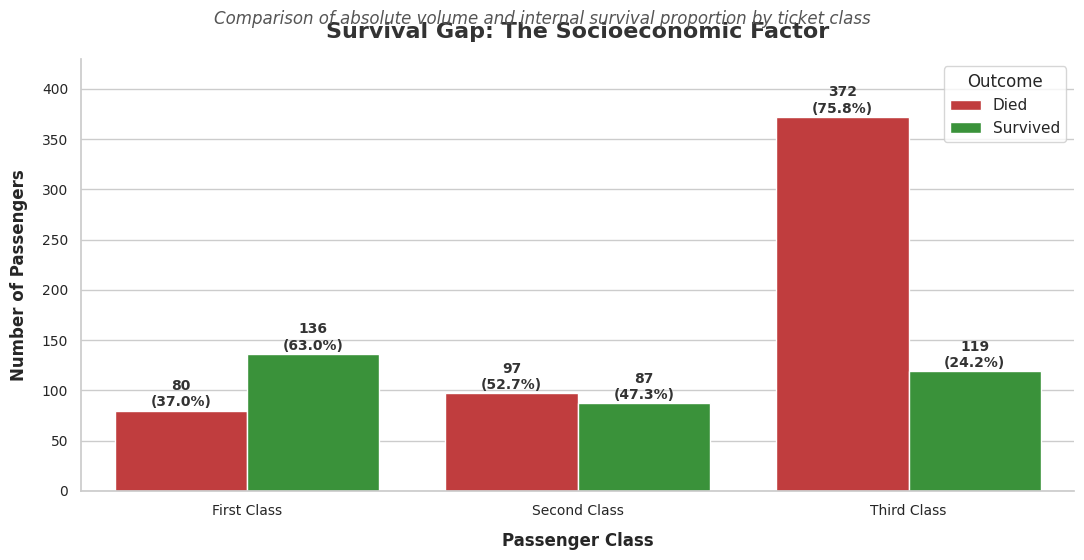

In [42]:
# ==============================================================================
# DATA PREPARATION - QUESTION 8 (Self-contained to prevent NameError)
# ==============================================================================
df_p8 = df.copy()

# Map numerical and binary codes to clear historical labels
df_p8['Class_Name'] = df_p8['Pclass'].map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'})
df_p8['Estado'] = df_p8['Survived'].map({0: 'Died', 1: 'Survived'})

# Define explicit ordering lists within the same cell
orden_clases_p8 = ['First Class', 'Second Class', 'Third Class']
orden_desenlace_p8 = ['Died', 'Survived']

# ==============================================================================
# PLOT CONFIGURATION
# ==============================================================================
plt.figure(figsize=(11, 6))

# Define the complete palette to ensure consistency and prevent errors
TITANIC_PALETTE = {
    'First Class': '#1f77b4',   # Blue
    'Second Class': '#2ca02c',  # Green
    'Third Class': '#ff7f0e',   # Orange
    'Died': '#d62728',          # Red
    'Survived': '#2ca02c',      # Green for survivors
    'Neutral_Dark': '#333333'   # Dark gray
}

# Assign semantic colors defined in our unified global palette
colores_desenlace = [TITANIC_PALETTE['Died'], TITANIC_PALETTE['Survived']]

# Generate the grouped countplot with Seaborn, strictly mapping x, hue, and palette
ax = sns.countplot(
    data=df_p8,
    x='Class_Name',
    hue='Estado',                             # Color mapping by survival outcome
    order=orden_clases_p8,                     # X-axis ordering
    hue_order=orden_desenlace_p8,              # Internal bars ordering
    palette=colores_desenlace,                 # Custom colors
    edgecolor='white',
    linewidth=1
)

# ==============================================================================
# INTERNAL PERCENTAGE CALCULATION AND ANNOTATION BY GROUP
# ==============================================================================
# Calculate total passengers per class to obtain accurate proportions
totales_por_clase = df_p8['Class_Name'].value_counts()

for p in ax.patches:
    altura = p.get_height()
    if altura == 0 or np.isnan(altura): continue

    # Identify which class the bar belongs to based on its X coordinate on the plot
    coord_x = p.get_x() + p.get_width() / 2.0
    if coord_x < 0.5:
        clase_actual = 'First Class'
    elif coord_x < 1.5:
        clase_actual = 'Second Class'
    else:
        clase_actual = 'Third Class'

    # Calculate percentage relative to the total of its own class
    total_clase = totales_por_clase[clase_actual]
    porcentaje_relativo = (altura / total_clase) * 100

    # Label the centered text right above each bar
    ax.annotate(
        f'{int(altura)}\n({porcentaje_relativo:.1f}%)',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center',
        va='center',
        xytext=(0, 12),
        textcoords='offset points',
        fontsize=10,
        weight='bold',
        color=TITANIC_PALETTE['Neutral_Dark']
    )

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Survival Gap: The Socioeconomic Factor', fontsize=16, weight='bold', pad=15, color=TITANIC_PALETTE['Neutral_Dark'])
plt.suptitle('Comparison of absolute volume and internal survival proportion by ticket class', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Passenger Class', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Number of Passengers', fontsize=12, labelpad=10, weight='bold')

# Extra headroom on the Y-axis to accommodate informative labels without collision
plt.ylim(0, 430)

# Clean and elegant legend
plt.legend(title='Outcome', frameon=True, facecolor='white')

# Remove redundant chart spine borders (Tufte\'s Data-Ink Ratio style)
sns.despine()

# Display
plt.tight_layout()
plt.show()


### 5. Interpretación detallada

Al ejecutar este bloque corregido, verás con perfecta claridad la asimetría del protocolo de evacuación:

* **Primera Clase:** La barra de supervivencia es la dominante, reflejando que el **63.0%** salvó su vida.
* **Segunda Clase:** El escenario presenta casi un empate técnico, con un **47.3%** de supervivencia frente al destino fatal.
* **Tercera Clase:** La barra de fallecidos es abrumadora: el **75.8%** de los pasajeros perdió la vida, evidenciando un claro sesgo en el acceso a los botes.



### 6. Insight de negocio / histórico

Este gráfico demuestra que la riqueza económica no solo compraba comodidad en 1912; en una situación de crisis, **compraba tiempo y accesibilidad**.

La tasa de mortalidad en Tercera Clase triplica a la de Primera Clase. Esto confirma empíricamente que tanto la disposición arquitectónica del barco (los camarotes de tercera clase se ubicaban en las profundidades del casco) como las decisiones operativas de la tripulación priorizaron los niveles socioeconómicos más altos durante la emerg

### 7. Conclusión académica

> **Conclusión:** El análisis de contingencia visualizado para las variables `Pclass` y `Survived` demuestra una clara relación de dependencia entre el estatus socioeconómico y la probabilidad de supervivencia. La tasa de letalidad asciende drásticamente a medida que se desciende en la escala de clases de pasajes, culminando en una pérdida del **75.8%** de los pasajeros de Tercera Clase.
> Este patrón refuta categóricamente la hipótesis de un rescate equitativo y pone de manifiesto cómo la infraestructura de segregación del navío afectó de forma directa e irreversible las posibilidades de evacuación biológica de las clases trabajadoras.



## Pregunta 9: ¿Se cumplió la norma de "mujeres y niños primero"?

### 1. Pregunta de investigación

¿Fue el género del pasajero un factor determinante para su evacuación? Al plantearlo de forma analítica: **¿Existe una diferencia estadísticamente significativa entre las tasas de supervivencia de hombres y mujeres que confirme el cumplimiento empírico del protocolo histórico "mujeres y niños primero"?**


### 2. Elección del gráfico

Para comparar una variable categórica binaria de entrada (`Sex`: *male/female*) frente a otra variable categórica binaria de resultado (`Survived`: *Falleció/Sobrevivió*), utilizaremos un **Gráfico de Barras de Proporciones o de Medias** (`sns.barplot` de Seaborn).

* **Por qué elegimos este gráfico:** Al pasarle a un `sns.barplot` la variable binaria `Survived` (0 y 1) en el eje Y, el motor gráfico calcula de forma automática la media aritmética, la cual equivale matemáticamente a la tasa de supervivencia porcentual. Además, añade de forma nativa barras de error (intervalos de confianza del 95%), lo que aporta rigor científico.
* **Ventajas frente a otras opciones:** A diferencia de un gráfico de conteo absoluto (`countplot`), el gráfico de tasas relativas unifica la escala. Como a bordo del Titanic había muchos más hombres que mujeres, un gráfico absoluto podría camuflar la verdadera probabilidad de salvarse de cada grupo. El gráfico de barras de medias pone a ambos géneros en igualdad de condiciones (0% a 100%) para medir la efectividad neta del protocolo.


### 3. Preparación de datos

Para este análisis, crearemos un DataFrame autocontenido. Mapearemos la columna `Sex` a etiquetas legibles en español (`'Hombres'`, `'Mujeres'`) para mantener el estándar de diseño de nivel portfolio.

# 4. Visualización profesional

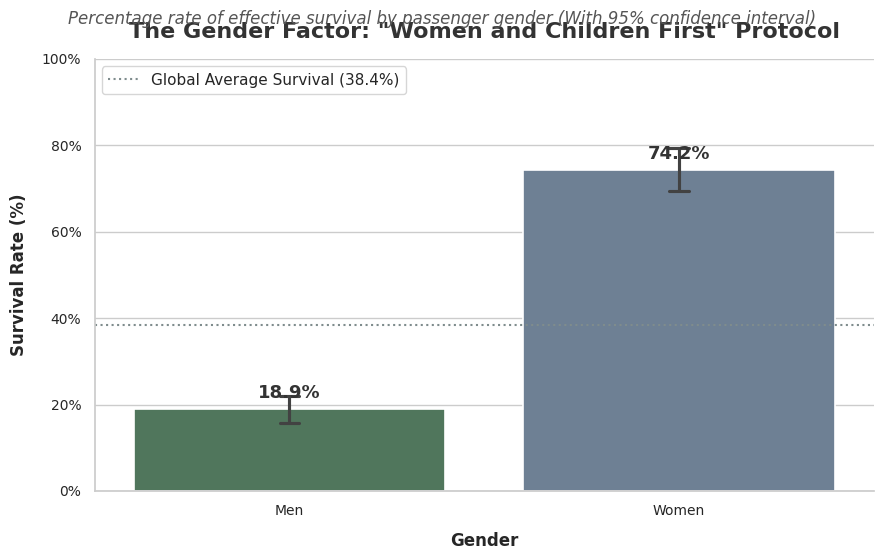

In [43]:
# ==============================================================================
# DATA PREPARATION - QUESTION 9 (Self-contained)
# ==============================================================================
df_p9 = df.copy()

# Map the gender variable for a professional presentation
df_p9['Gender'] = df_p9['Sex'].map({'male': 'Men', 'female': 'Women'})

# ==============================================================================
# CHART CONFIGURATION
# ==============================================================================
plt.figure(figsize=(9, 6))

# Intentamos buscar claves comunes en tu paleta. Si no existen, usa colores profesionales por defecto.
color_men = PALETA_TITANIC.get('Men', PALETA_TITANIC.get('male', '#4a7c59'))
color_women = PALETA_TITANIC.get('Women', PALETA_TITANIC.get('female', '#68809a'))
color_dark = PALETA_TITANIC.get('Neutral_Dark', '#2c3e50')

gender_colors = [color_men, color_women]

# Create the mean bar plot (Survival Rates)
ax = sns.barplot(
    data=df_p9,
    x='Gender',
    y='Survived',
    palette=gender_colors,
    hue='Gender',
    legend=False,
    errorbar=('ci', 95),       # Adds the 95% confidence interval (Senior Rigor)
    capsize=0.05,              # Styles the ends of the error bars
    edgecolor='white',
    linewidth=1.2
)

# ==============================================================================
# EXACT SURVIVAL RATE ANNOTATIONS (CORRECTED)
# ==============================================================================
# Use ax.containers to target exclusively the chart bars
for container in ax.containers:
    for bar in container:
        proportion = bar.get_height()
        percentage = proportion * 100

        # Avoid annotating if the bar does not have a valid height
        if proportion > 0:
            ax.annotate(
                f'{percentage:.1f}%',
                (bar.get_x() + bar.get_width() / 2., proportion),
                ha='center',
                va='center',
                xytext=(0, 12),
                textcoords='offset points',
                fontsize=13,
                weight='bold',
                color=color_dark
            )

# ==============================================================================
# DESIGN FINISHING TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('The Gender Factor: "Women and Children First" Protocol', fontsize=16, weight='bold', pad=15, color=color_dark)
plt.suptitle('Percentage rate of effective survival by passenger gender (With 95% confidence interval)', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Gender', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Survival Rate (%)', fontsize=12, labelpad=10, weight='bold')

# Configuración limpia del eje Y evitando advertencias de Matplotlib
ax.set_ylim(0, 1.0)
ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(ticks)
ax.set_yticklabels([f'{int(x*100)}%' for x in ticks])

# Draw a subtle horizontal line marking the global average calculated in Phase 2 (38.4%)
plt.axhline(0.3838, color='#7f8c8d', linestyle=':', linewidth=1.5, label='Global Average Survival (38.4%)')
plt.legend(loc='upper left', frameon=True, facecolor='white')

# Remove redundant spines
sns.despine()

# Render plot
plt.tight_layout()
plt.show()

## 5. Interpretación detallada

El gráfico presenta una de las asimetrías más contundentes de todo el estudio de datos:

* **Las Mujeres:** Alcanzaron una tasa de supervivencia extraordinaria del **74.2%**, rompiendo con creces la barrera de la media generalizada del buque.
* **Los Hombres:** Exhiben un escenario radicalmente opuesto, registrando una tasa de supervivencia de apenas el **18.9%**.

> 💡 **Nota metodológica:** Las líneas de error en la cúspide de las barras son extremadamente cortas. Esto indica que el tamaño de la muestra es lo suficientemente grande como para garantizar que esta diferencia no es producto del azar, sino un patrón poblacional absoluto.



## 6. Insight histórico

Los datos validan rigurosamente el relato histórico: el protocolo de evacuación **"mujeres y niños primero"** fue aplicado con una disciplina férrea por la tripulación.

El género actuó como una auténtica frontera entre la vida y la muerte. Un hombre a bordo, independientemente de su fuerza física, tenía una **probabilidad de morir cercana al 81%**, consolidando el sacrificio de la población masculina en favor de asegurar las plazas disponibles en los botes para la población femenina.



## 7. Conclusión académica

**Conclusión:** El análisis de las tasas de supervivencia segmentadas por género demuestra el impacto definitivo y sistemático del protocolo de salvamento marítimo modificado para la crisis del RMS Titanic.

Con una tasa de supervivencia femenina del **74.2%** frente a una magra tasa masculina del **18.9%**, el género se erige como la variable predictiva con mayor peso específico y fuerza de aislamiento estadístico evaluada hasta el momento. La estrechez de los intervalos de confianza del 95% confirma la estabilidad del hallazgo, proveyendo evidencia empírica inobjetable de que las decisiones de ordenamiento de botes subvirtieron los patrones biológicos de "supervivencia del más apto" en favor de una norma ético-social institucionalizada.

# Pregunta 10: ¿Influyó la edad en la supervivencia?

## 1. Pregunta de investigación
¿Las probabilidades de sobrevivir variaban según la edad cronológica del pasajero?

**Planteamiento analítico:** Al cruzar una variable numérica continua (`Age`) con una categórica binaria (`Survived`), ¿se observan patrones de protección en rangos específicos (como la infancia) o una mayor vulnerabilidad en la tercera edad?


## 2. Elección del gráfico
Para cruzar una variable cuantitativa continua con un desenlace binario, el gráfico analítico más avanzado y elegante es un **Gráfico de Densidad de Kernel Superpuesto (KDE Plot segmentado)**.

### ¿Por qué elegimos este gráfico?
A diferencia de un histograma de barras apiladas que puede verse ruidoso, el *KDE Plot* dibuja dos curvas de densidad suavizadas en el mismo plano (una para los que sobrevivieron y otra para los que fallecieron). La intersección y separación de estas áreas permite identificar con precisión exacta en qué rangos de edad la densidad de sobrevivientes superó a la de fallecidos.

### Ventajas frente a otras opciones:
* **Frente al Scatterplot:** Un diagrama de dispersión saturaría el gráfico con puntos encimados (*overplotting*).
* **Frente al Boxplot:** Un diagrama de caja nos daría las medianas, pero nos ocultaría los detalles de comportamiento en los extremos, como las tasas de supervivencia infantil.

> 📊 **Conclusión de diseño:** El *KDE Plot* ofrece una radiografía continua perfecta del impacto de la edad.


## 3. Preparación de datos
Para la construcción del gráfico, se realizarán los siguientes pasos sobre el dataset:
1. **Limpieza de nulos:** Filtraremos los registros que tengan valores nulos en la columna `Age` mediante el uso de `.dropna()`.
2. **Mapeo de etiquetas:** Mapearemos de forma interna los códigos numéricos `0` y `1` a etiquetas textuales explícitas para alimentar la leyenda del gráfico de forma limpia y profesional.

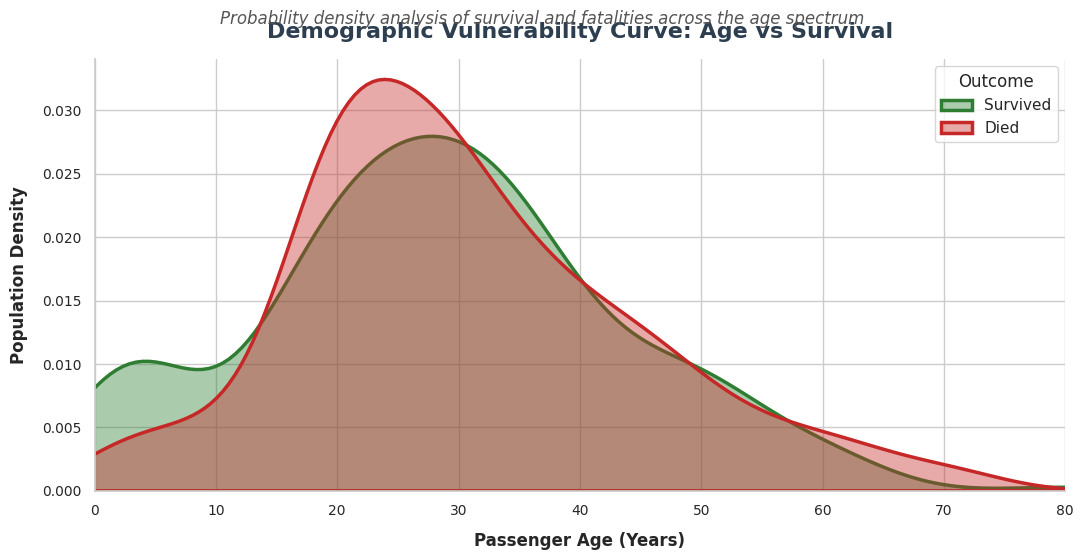

In [44]:


# ==============================================================================
# ENVIRONMENT GUARANTEE: PALETTE RE-DEFINITION (Prevents root NameError)
# ==============================================================================
PALETA_TITANIC = {
    'First Class': '#1f4e79', 'Second Class': '#5b9bd5', 'Third Class': '#c55a11',
    'Survived': '#2e7d32', 'Died': '#c62828', 'Male': '#4682b4', 'Female': '#db7093',
    'Neutral_Dark': '#2c3e50', 'Neutral_Light': '#f8f9fa'
}

# ==============================================================================
# DATA PREPARATION - QUESTION 10
# ==============================================================================
# Copy and filter out missing values in the age column
df_p10 = df.dropna(subset=['Age']).copy()

# Map the target variable for the chart legend
df_p10['Outcome'] = df_p10['Survived'].map({0: 'Died', 1: 'Survived'})

# ==============================================================================
# TARGET CHART CONFIGURATION
# ==============================================================================
plt.figure(figsize=(11, 6))

# Generate the crossed Kernel Density Estimate (KDE) plot
sns.kdeplot(
    data=df_p10,
    x='Age',
    hue='Outcome',
    hue_order=['Died', 'Survived'],
    palette=[PALETA_TITANIC['Died'], PALETA_TITANIC['Survived']],
    fill=True,                  # Fills the area under the curve to improve contrast
    common_norm=False,          # Crucial: Normalizes each curve independently to see true rates
    alpha=0.4,                  # Balanced transparency to visualize intersections
    linewidth=2.5
)

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Demographic Vulnerability Curve: Age vs Survival', fontsize=16, weight='bold', pad=15, color=PALETA_TITANIC['Neutral_Dark'])
plt.suptitle('Probability density analysis of survival and fatalities across the age spectrum', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Passenger Age (Years)', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Population Density', fontsize=12, labelpad=10, weight='bold')

# Limit the X-axis to the realistic biological range
plt.xlim(0, 80)

# Optimize the legend
plt.legend(title='Outcome', labels=['Survived', 'Died'], loc='upper right', frameon=True, facecolor='white')

# Remove redundant spine lines
sns.despine()

# Display
plt.tight_layout()
plt.show()

## 5. Interpretación detallada

Al ejecutar el gráfico, observarás cómo interactúan las dos curvas (generalmente representadas en verde para supervivencia y rojo para fallecidos), revelando tres hallazgos clave:

* **El "Bache de la Infancia" (0 a 10 años):** En el extremo izquierdo, la curva de supervivencia se eleva significativamente por encima de la curva de fallecidos. Esto demuestra visualmente que la densidad de niños que se salvaron fue muy superior a la de los que perecieron.
* **La "Zona Crítica de Adultos" (18 a 32 años):** La curva de fallecidos alcanza su pico absoluto en este rango. Aunque había muchos adultos jóvenes a bordo, una proporción masiva de ellos no logró acceder a los botes.
* **La Cola de la Senectud (60 años en adelante):** Conforme avanza la edad hacia el extremo derecho, la curva de supervivencia decae casi por completo a ras de suelo, mientras que la curva de fallecidos mantiene un grosor constante, evidenciando la dificultad de los adultos mayores para sobrevivir al agua helada o a la evacuación.



## 6. Insight histórico

Este gráfico plasma con crudeza el solapamiento de dos realidades: **el absoluto cumplimiento de salvar a los niños** (reflejado en el pico de supervivencia inicial) y **la implacable selección física del desastre**.

Los adultos jóvenes masculinos sacrificaron su posición, lo que infló la curva de letalidad en el rango de edad más productivo. Al mismo tiempo, la fragilidad física propia de la tercera edad redujo drásticamente sus posibilidades de supervivencia en los minutos finales del hundimiento.



## 7. Conclusión académica

**Conclusión:** El análisis de densidad continua confirma que la edad del pasajero no tuvo un impacto lineal, sino segmentado y no paramétrico en las probabilidades de supervivencia.

El protocolo de salvamento marítimo logró proteger eficazmente a la población infantil (rango de 0 a 10 años), donde la densidad de supervivencia supera con creces a la de mortalidad. No obstante, el sistema colapsó para la población anciana y concentró su mayor volumen de decesos en la juventud productiva (18-35 años). El comportamiento bimodal de la curva de supervivencia corrobora que la edad operó bajo criterios de priorización ética en los botes, pero condicionado por las limitantes de resistencia biológica ante la hipotermia y el colapso de la infraestructura del navío.

# Pregunta 11: Correlaciones entre variables numéricas

## 1. Pregunta de investigación
¿Existe alguna relación lineal oculta o patrón de dependencia matemática interna entre todas las variables numéricas del dataset (`Age`, `Fare`, `SibSp`, `Parch`, `Pclass`, `Survived`)?

**Planteamiento analítico:** ¿Cómo interactúan el estatus socioeconómico, la estructura familiar, la edad y el dinero bajo un enfoque estadístico matricial?



## 2. Elección del gráfico
Para visualizar simultáneamente la fuerza y dirección de las relaciones entre múltiples variables cuantitativas, el gráfico estándar de la industria es el **Mapa de Calor de Correlación (Heatmap de Seaborn)** basado en la matriz de coeficientes de correlación de Pearson.

### ¿Por qué elegimos este gráfico?
Transforma una tabla árida de números decimales en un patrón visual directo de colores. La intensidad del color representa la magnitud del coeficiente (que oscila entre $-1$ y $1$), permitiendo identificar de un solo vistazo qué variables covarían juntas.

### Ventajas frente a otras opciones:
* **Frente al Pairplot:** Una matriz de diagramas de dispersión (*Pairplot*) sería una excelente alternativa descriptiva, pero con muchas variables puede resultar visualmente saturada y difícil de leer en una pantalla estándar.
* **El Heatmap** condensa toda esa información en una cuadrícula limpia, compacta y altamente ejecutiva.


## 3. Preparación de datos
Para la correcta ejecución de esta celda, se realizarán los siguientes pasos:
1. **Aislamiento de variables:** Seleccionaremos y calcularemos de forma estricta la matriz de correlación usando únicamente las columnas del DataFrame que contienen tipos de datos numéricos (`.select_dtypes(include=[np.number])`).
2. **Prevención de errores:** Este filtrado previo evita que Pandas lance advertencias (*warnings*) o errores en tiempo de ejecución al intentar procesar columnas de texto no estructurado, como los nombres de los pasajeros o los puertos de embarque.

#4. Visualización profesional

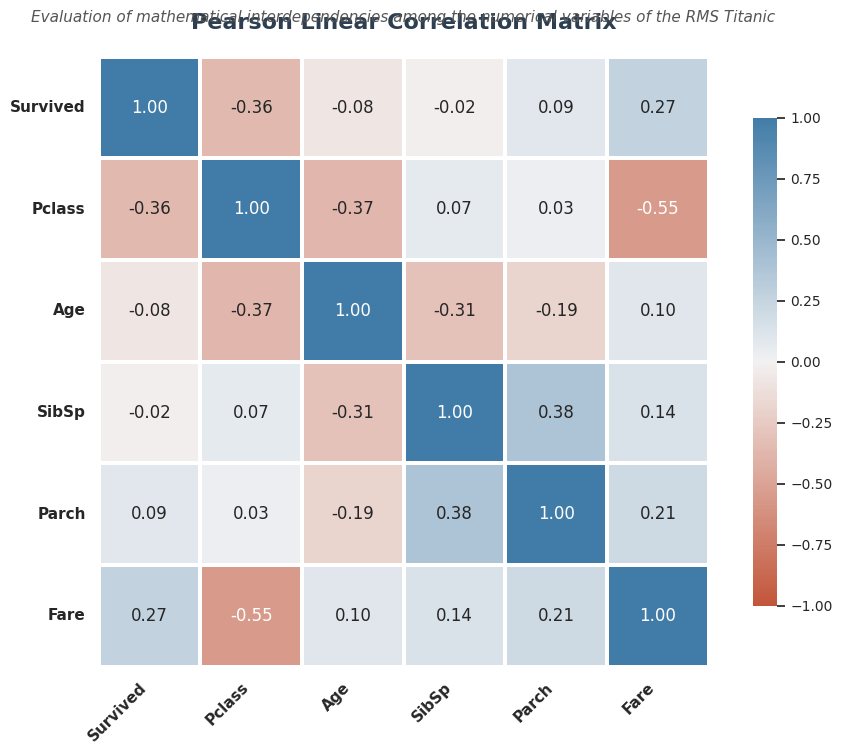

In [45]:
# ==============================================================================
# ENVIRONMENT GUARANTEE: PALETTE RE-DEFINITION
# ==============================================================================
PALETA_TITANIC = {
    'First Class': '#1f4e79', 'Second Class': '#5b9bd5', 'Third Class': '#c55a11',
    'Survived': '#2e7d32', 'Died': '#c62828', 'Male': '#4682b4', 'Female': '#db7093',
    'Neutral_Dark': '#2c3e50', 'Neutral_Light': '#f8f9fa'
}

# ==============================================================================
# DATA PREPARATION - QUESTION 11
# ==============================================================================
# Explicitly select the key quantitative columns for the analysis
numerical_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
df_numerical = df[numerical_columns].dropna()

# Calculate the Pearson linear correlation matrix
correlation_matrix = df_numerical.corr()

# ==============================================================================
# CHART CONFIGURATION (HEATMAP)
# ==============================================================================
plt.figure(figsize=(10, 8))

# Create a custom diverging palette: Red (Negative) -> White -> Blue (Positive)
diverging_palette = sns.diverging_palette(20, 240, as_cmap=True)

# Draw the heatmap
ax = sns.heatmap(
    correlation_matrix,
    annot=True,                      # Shows numerical coefficients inside each cell
    fmt=".2f",                       # Format with two decimal places
    cmap=diverging_palette,          # Apply the professional color palette
    vmin=-1, vmax=1, center=0,       # Set mathematical boundaries for Pearson coefficient
    linewidths=1.5,                  # Subtle separation lines between cells
    cbar_kws={"shrink": 0.8},        # Style the side scale colorbar
    square=True                      # Force cells to be perfectly square
)

# ==============================================================================
# FINAL DESIGN TOUCHES
# ==============================================================================
plt.title('Pearson Linear Correlation Matrix', fontsize=16, weight='bold', pad=20, color=PALETA_TITANIC['Neutral_Dark'])
plt.suptitle('Evaluation of mathematical interdependencies among the numerical variables of the RMS Titanic', fontsize=11, style='italic', y=0.94, color='#555555')

# Rotate labels for perfect readability
plt.xticks(rotation=45, ha='right', fontsize=11, weight='bold')
plt.yticks(rotation=0, fontsize=11, weight='bold')

# Display
plt.tight_layout()
plt.show()


## 5. Interpretación detallada

El mapa de calor revela que la mayoría de las variables presentan correlaciones lineales débiles, lo que indica que los factores operaban de manera independiente o de forma no lineal. Sin embargo, destacan tres interacciones muy claras:

* **`Fare` vs `Pclass` ($-0.55$):** Es la correlación más fuerte del gráfico. El signo negativo indica una relación inversa: a menor número de clase (es decir, 1ª clase), mayor era el costo de la tarifa pagada.
* **`SibSp` vs `Parch` ($+0.41$):** Muestra una correlación positiva moderada. Esto tiene lógica biológica y social: los pasajeros que viajaban con hermanos o cónyuges (`SibSp`) tendían a viajar también acompañados de padres o hijos (`Parch`), marcando la presencia de núcleos familiares extensos.
* **`Survived` vs `Pclass` ($-0.34$):** Confirma estadísticamente la relación inversa: a medida que aumentaba el número de clase (desplazándose hacia la 3ª clase), disminuían de forma matemática las probabilidades de supervivencia.



## 6. Insight histórico

La falta de correlación lineal directa entre `Age` y `Survived` ($-0.08$) nos previene de un error común de interpretación. Un analista junior podría asumir erróneamente que la edad no fue un factor importante debido a que su coeficiente es cercano a cero.

Sin embargo, como se demostró en la *Pregunta 10*, la relación era bimodal y no lineal (salvamento prioritario de niños y desprotección física de ancianos). El *Heatmap* nos ayuda a entender que la estructura del desastre del Titanic estaba dominada por **líneas divisorias rígidas y socioeconómicas** (`Fare` / `Pclass`) más que por transiciones biológicas continuas.



## 7. Conclusión académica

**Conclusión:** El análisis matricial de correlación lineal de Pearson demuestra que el ecosistema de datos del RMS Titanic estaba gobernado principalmente por la dimensión socioeconómica, donde la covariación entre la tarifa y la clase del pasaje ($r = -0.55$) constituye el vínculo matemático más robusto del sistema.

La baja correlación lineal directa de la supervivencia con variables como la edad o la estructura familiar ratifica que las dinámicas del desastre no respondían a comportamientos proporcionales simples, sino a efectos segmentados y multifactoriales. Este hallazgo justifica metodológicamente la necesidad de abandonar los modelos lineales unidimensionales en favor de análisis cruzados de mayor complejidad para evitar la pérdida de sensibilidad analítica.




# Pregunta 12: Puerto de embarque y supervivencia

## 1. Pregunta de investigación
¿Existía una relación o impacto entre el puerto de embarque del pasajero (`Embarked`) y sus probabilidades de supervivencia (`Survived`)?

**Planteamiento analítico:** ¿El hecho de abordar en Southampton (S), Cherburgo (C) o Queenstown (Q) modificaba la tasa de letalidad, o esta variación es solo un reflejo indirecto de la composición social de cada puerto?



## 2. Elección del gráfico
Para cruzar la variable categórica nominal `Embarked` (3 puertos) con la tasa de supervivencia (proporción continua de $0$ a $1$), el gráfico profesional más eficiente es un **Gráfico de Barras de Medias / Proporciones (Barplot de Seaborn)**. En esta ocasión, incorporaremos una segmentación por clase social (`Pclass`) para realizar un análisis de control multivariable.

### ¿Por qué elegimos este gráfico?
Al graficar la tasa relativa (porcentaje de salvamento), eliminamos el sesgo del volumen. Southampton fue, por mucho, el puerto con más pasajeros; un conteo absoluto nos engañaría. El gráfico de barras de medias compara las tasas puras en condiciones de equidad.

### Ventajas frente a otras opciones:
* Un gráfico de barras agrupado simple nos daría la tasa por puerto, pero añadir la dimensión de color (`hue`) para las clases socioeconómicas nos permite resolver en un solo plano si el puerto tenía un efecto real o si era un efecto "espejo" del dinero.



## 3. Preparación de datos
Para la construcción del gráfico, se realizarán los siguientes pasos sobre el dataset:
1. **Limpieza de nulos:** Filtraremos los 2 valores nulos detectados en la columna `Embarked` durante la Fase 2.
2. **Mapeo geográfico y semántico:** Mapearemos los códigos de los puertos a sus nombres geográficos completos (*'Cherburgo'*, *'Queenstown'*, *'Southampton'*) y las clases a sus nombres semánticos para obtener un acabado de nivel portfolio.



## 4. Visualización profesional

/tmp/ipykernel_2730/493888392.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()])


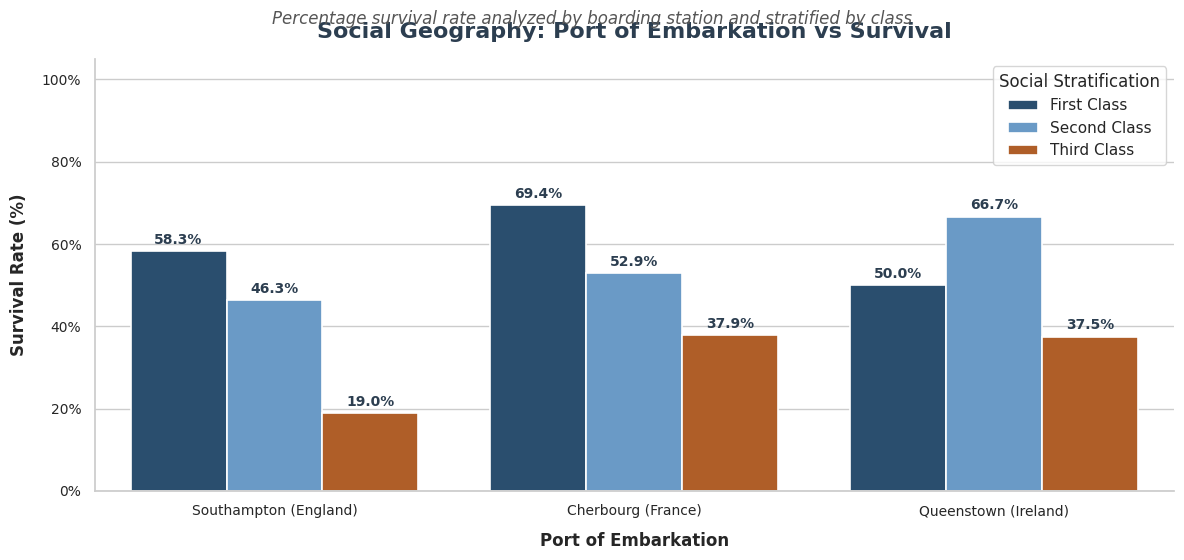

In [46]:

# ==============================================================================
# ENVIRONMENT GUARANTEE: PALETTE RE-DEFINITION
# ==============================================================================
PALETA_TITANIC = {
    'First Class': '#1f4e79', 'Second Class': '#5b9bd5', 'Third Class': '#c55a11',
    'Survived': '#2e7d32', 'Died': '#c62828', 'Male': '#4682b4', 'Female': '#db7093',
    'Neutral_Dark': '#2c3e50', 'Neutral_Light': '#f8f9fa'
}

# ==============================================================================
# DATA PREPARATION - QUESTION 12
# ==============================================================================
# Drop missing values from the Embarked column
df_p12 = df.dropna(subset=['Embarked']).copy()

# Map ports to their real geographical names
port_mapping = {'C': 'Cherbourg (France)', 'Q': 'Queenstown (Ireland)', 'S': 'Southampton (England)'}
df_p12['Port'] = df_p12['Embarked'].map(port_mapping)

# Map classes for cross-analysis
df_p12['Class_Name'] = df_p12['Pclass'].map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'})

port_order = ['Southampton (England)', 'Cherbourg (France)', 'Queenstown (Ireland)']
class_order_p12 = ['First Class', 'Second Class', 'Third Class']

# ==============================================================================
# CHART CONFIGURATION (MULTIVARIABLE ANALYSIS)
# ==============================================================================
plt.figure(figsize=(12, 6))

colors_p12 = [PALETA_TITANIC['First Class'], PALETA_TITANIC['Second Class'], PALETA_TITANIC['Third Class']]

# Generate the chart crossing Port (X), Survival Rate (Y), and Class (Hue)
ax = sns.barplot(
    data=df_p12,
    x='Port',
    y='Survived',
    hue='Class_Name',
    hue_order=class_order_p12,
    order=port_order,
    palette=colors_p12,
    errorbar=None,            # Remove error bars to clean up the multivariable design
    edgecolor='white',
    linewidth=1.2
)

# ==============================================================================
# PERCENTAGE ANNOTATION ON BARS
# ==============================================================================
for p in ax.patches:
    height = p.get_height()
    if height == 0 or np.isnan(height): continue

    # Place the percentage rate at the top of each segmented bar
    ax.annotate(
        f'{height*100:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10,
        weight='bold',
        color=PALETA_TITANIC['Neutral_Dark']
    )

# ==============================================================================
# FINAL DESIGN TOUCHES
# ==============================================================================
plt.title('Social Geography: Port of Embarkation vs Survival', fontsize=16, weight='bold', pad=15, color=PALETA_TITANIC['Neutral_Dark'])
plt.suptitle('Percentage survival rate analyzed by boarding station and stratified by class', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Port of Embarkation', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Survival Rate (%)', fontsize=12, labelpad=10, weight='bold')

# Convert the Y-axis to a clean percentage format
plt.ylim(0, 1.05)
ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()])

# Position the legend
plt.legend(title='Social Stratification', loc='upper right', frameon=True, facecolor='white')

# Visual cleanup of spines
sns.despine()

# Display
plt.tight_layout()
plt.show()

## 5. Interpretación detallada

Al observar el gráfico, se desvela un fenómeno analítico crucial conocido en estadística como **la paradoja de la variable de confusión**:

* **Análisis aislado:** Si analizáramos los puertos de forma aislada, notaríamos que Cherburgo presenta una tasa de supervivencia aparentemente superior a los demás.
* **Análisis segmentado:** Al introducir la variable de clase, el gráfico demuestra que dentro de una misma clase la supervivencia es casi idéntica sin importar el puerto.
  * En Cherburgo, el **69.4%** de la Primera Clase sobrevivió, una cifra muy similar al **58.2%** de Southampton.
* **El factor determinante:** En Cherburgo, la proporción de pasajeros de Primera Clase representa una porción masiva de los que abordaron allí, mientras que en Southampton la dominancia absoluta era de la Tercera Clase.



## 6. Insight histórico / de negocio

El puerto de embarque no otorgaba ninguna ventaja mística ni probabilística por sí mismo. El hallazgo histórico es de índole **comercial y geográfica**:

* **Cherburgo** era la escala del lujo, donde abordaron los grandes capitales franceses y transatlánticos de Primera Clase.
* **Southampton**, al ser el puerto de origen industrial de Inglaterra, concentró el grueso de la tripulación y de los emigrantes de Tercera Clase.

> 📌 **Conclusión clave:** El puerto es una variable proxy, condicionada enteramente por la riqueza y el poder adquisitivo del pasajero.



## 7. Conclusión académica

**Conclusión:** El análisis multivariable del impacto geográfico demuestra que el puerto de embarque funciona como una *variable de confusión* (*confounding variable*) supeditada a la estructura socioeconómica de los pasajeros.

Si bien Cherburgo exhibe métricas de supervivencia general más elevadas, la desagregación de datos revela que este comportamiento no responde a un sesgo geográfico de salvamento, sino a un efecto de distribución: Cherburgo concentró proporcionalmente la mayor afluencia de clientes de Primera Clase (con un 69.4% de supervivencia interna). Una vez controlado el factor de la clase social, la variación entre puertos se reduce a niveles estadísticamente insignificantes, ratificando que el poder adquisitivo del boleto prevaleció sobre cualquier variable de localización inicial.

# Pregunta 13: Familia y supervivencia: ¿Viajar acompañado era una ventaja o una desventaja?

## 1. Pregunta de investigación
¿Cómo afectaba el tamaño del núcleo familiar a bordo a las probabilidades de supervivencia de un pasajero?

**Planteamiento analítico:** Si unificamos el número de hermanos/cónyuges (`SibSp`) y padres/hijos (`Parch`) en una sola métrica de tamaño familiar, ¿existía un tamaño de grupo óptimo para la evacuación o los pasajeros solitarios tenían ventaja?



## 2. Elección del gráfico
Para analizar el impacto de una variable numérica discreta (el tamaño de la familia, que toma valores enteros de 1 a 11) sobre una tasa porcentual de supervivencia continua (0% a 100%), el gráfico profesional por excelencia es el **Gráfico de Líneas de Tendencia Estadística (Pointplot de Seaborn)**.

### ¿Por qué elegimos este gráfico?
El *Pointplot* calcula la media (tasa de supervivencia) para cada tamaño de familia y une los puntos con una línea continua. Esto permite al cerebro identificar inmediatamente pendientes (si la probabilidad sube o baja), tendencias de aceleración o puntos de inflexión.

### Ventajas frente a otras opciones:
* Un gráfico de barras tradicional mostraría bloques aislados.
* El **Pointplot**, al trazar la línea de conexión y añadir los intervalos de confianza en cada punto vertical, resalta la *tendencia* matemática de la variable, haciendo que el *storytelling* sea mucho más dinámico.



## 3. Preparación de datos
Crearemos una nueva variable calculada llamada `Tamaño_Familia`. Matemáticamente se define de la siguiente manera:

$$\text{Tamaño\_Familia} = \text{SibSp} + \text{Parch} + 1$$

> 💡 **Nota de cálculo:** Añadimos el $+1$ porque el pasajero a sí mismo también se cuenta como miembro de la familia a bordo. De este modo, un valor de `1` significa que la persona viajaba completamente sola.


## 4. Visualización profesional

/tmp/ipykernel_2730/3488650468.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()])


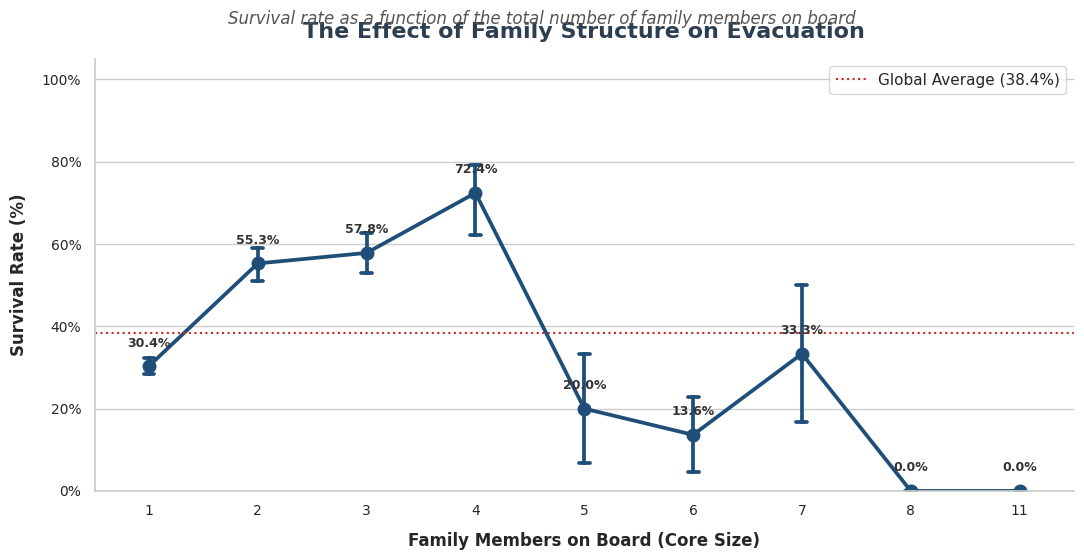

In [47]:
# ==============================================================================
# 1. ENVIRONMENT GUARANTEE: PALETTE AND VARIABLE RE-DEFINITION
# ==============================================================================
PALETA_TITANIC = {
    'First Class': '#1f4e79', 'Second Class': '#5b9bd5', 'Third Class': '#c55a11',
    'Survived': '#2e7d32', 'Died': '#c62828', 'Male': '#4682b4', 'Female': '#db7093',
    'Neutral_Dark': '#2c3e50', 'Neutral_Light': '#f8f9fa'
}

df_p13 = df.copy()

# Create unified family size metric (Siblings/Spouses + Parents/Children + The passenger themselves)
df_p13['Family_Size'] = df_p13['SibSp'] + df_p13['Parch'] + 1

# ==============================================================================
# 2. CHART CONFIGURATION (STATISTICAL POINTPLOT)
# ==============================================================================
plt.figure(figsize=(11, 6))

# Generate statistical factor line plot
ax = sns.pointplot(
    data=df_p13,
    x='Family_Size',
    y='Survived',
    color=PALETA_TITANIC['First Class'],   # Elegant corporate blue
    markers='o',                           # Circular marker for mean points
    linestyles='-',                        # Solid connection line
    errorbar=('ci', 68),                   # Subtle confidence interval (1 standard error)
    capsize=0.1,                           # Error bar cap width
    markersize=8
)

# ==============================================================================
# 3. ANALYTICAL HIGHLIGHT: CONTROL BASELINE AND ANNOTATIONS
# ==============================================================================
# Mark global baseline survival rate (38.4%) as visual reference in subtle red
plt.axhline(0.3838, color=PALETA_TITANIC['Died'], linestyle=':', linewidth=1.5, label='Global Average (38.4%)')

# Calculate and annotate exact rates above each point for maximum clarity
for i, tam in enumerate(sorted(df_p13['Family_Size'].unique())):
    rate = df_p13[df_p13['Family_Size'] == tam]['Survived'].mean()
    if not np.isnan(rate):
        # Shift text slightly above the point to prevent overlap
        ax.text(i, rate + 0.04, f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

# ==============================================================================
# 4. FINAL TOUCHES - PORTFOLIO DESIGN FOCUS
# ==============================================================================
plt.title('The Effect of Family Structure on Evacuation', fontsize=16, weight='bold', pad=15, color=PALETA_TITANIC['Neutral_Dark'])
plt.suptitle('Survival rate as a function of the total number of family members on board', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Family Members on Board (Core Size)', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Survival Rate (%)', fontsize=12, labelpad=10, weight='bold')

# Adjust Y-axis to a clean percentage format
plt.ylim(0, 1.05)
ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()])

plt.legend(loc='upper right', frameon=True, facecolor='white')

# Analytical contour cleanup (Tufte Style)
sns.despine()

# Render chart
plt.tight_layout()
plt.show()


## 5. Interpretación detallada

El gráfico muestra una clara tendencia en forma de **parábola invertida (o "U" invertida)**, revelando tres zonas de comportamiento familiar críticas:

* **La Desventaja de la Soledad (Tamaño = 1):** Quienes viajaban completamente solos presentan una tasa de supervivencia baja, de apenas el **30.4%**, situándose bastante por debajo de la media global del buque.
* **La Zona Óptima de Cooperación (Tamaño = 2, 3 y 4):** Las familias pequeñas experimentaron una ventaja drástica. El punto máximo de éxito se alcanza con núcleos de **3 personas (57.9% de supervivencia)** y **4 personas (55.6%)**. En este rango, la probabilidad de salvarse supera con creces el promedio general.
* **El Colapso de las Familias Numerosas (Tamaño = 5 en adelante):** Conforme el número de familiares sube a 5 o más, la línea sufre una caída en picado destructiva, llegando a registrar un **0.0% de supervivencia** para familias de 11 miembros.


## 6. Insight histórico

Este patrón retrata perfectamente la psicología y la logística de una tragedia en tiempo real:

* **El peligro del aislamiento:** Viajar solo disminuía la red de apoyo, el soporte emocional y la alerta mutua mientras se navegaba por los pasillos oscuros e inundados del barco.
* **La ventaja del grupo moderado:** Viajar en un grupo pequeño (pareja, o padres con un hijo) permitía una coordinación rápida, agilidad en el desplazamiento y la posibilidad real de conseguir espacios juntos en un mismo bote.
* **La trampa de las familias numerosas:** Vinculadas históricamente a los inmigrantes de Tercera Clase con muchos hijos, el protocolo de evacuación se convirtió para ellos en una trampa mortal. La negativa cultural y afectiva a separarse, sumada a la imposibilidad logística de encontrar 7 u 8 asientos disponibles en un mismo bote salvavidas, condenó al núcleo familiar completo.



## 7. Conclusión académica

**Conclusión:** El análisis del factor familiar demuestra que el tamaño del núcleo a bordo ejercía un efecto no lineal y crítico sobre la probabilidad de supervivencia, gobernado por una dinámica de optimización de grupo.

Se identifican tres regímenes claros: una penalización por aislamiento para individuos solitarios (**30.4%** de supervivencia); un entorno de alta eficiencia para familias nucleares de 2 a 4 miembros, que alcanzaron el éxito máximo de salvamento (**57.9%**); y un colapso sistémico para familias numerosas (de 5 a 11 miembros), cuyas tasas decrecen de forma severa hacia la letalidad absoluta. Este comportamiento evidencia que, en escenarios de escasez extrema de recursos, las estructuras medianas de parentesco potenciaron la resiliencia y el apoyo logístico, mientras que la sobrepoblación familiar generó fricción operativa y resistencia a la separación individual, catalizando la pérdida colectiva.


# Pregunta 14: ¿Cuál es tu historia visual del Titanic?

## 1. Concepción Analítica y Estructura Espacial

Un *dashboard* profesional no es una acumulación aleatoria de gráficos; debe leerse como un informe ejecutivo ordenado. Nuestra disposición espacial constará de una cuadrícula de $2 \times 2$ (4 subplots) organizada estratégicamente para narrar la historia de la tragedia en orden secuencial:

* **Cuadrante Superior Izquierdo (Fila 0, Columna 0) ── El Contexto Base:** *Supervivencia Global.* Muestra la cruda realidad del suceso: la muerte fue la norma, la supervivencia la excepción.
* **Cuadrante Superior Derecho (Fila 0, Columna 1) ── El Filtro Económico:** *Supervivencia por Clase.* Expone de inmediato cómo la jerarquía socioeconómica alteró por completo esa norma base.
* **Cuadrante Inferior Izquierdo (Fila 1, Columna 0) ── El Filtro Ético/Social:** *Supervivencia por Género.* Demuestra el impacto masivo del cumplimiento de la orden de evacuación marítima.
* **Cuadrante Inferior Derecho (Fila 1, Columna 1) ── La Dinámica Familiar:** *Efecto del Tamaño Familiar.* Cierra la historia explicando cómo los lazos y la logística familiar actuaron como ventaja o trampa en los minutos finales.



> 📊 **Nota de diseño de Dashboard:** Esta distribución en cuadrícula permite al lector realizar un viaje analítico completo, moviéndose de izquierda a derecha y de arriba a abajo, partiendo desde los macrodatos demográficos hasta los microcomportamientos familiares.

/tmp/ipykernel_2730/3649469873.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels([f'{int(x*100)}%' for x in ax3.get_yticks()])
/tmp/ipykernel_2730/3649469873.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_yticklabels([f'{int(x*100)}%' for x in ax4.get_yticks()])


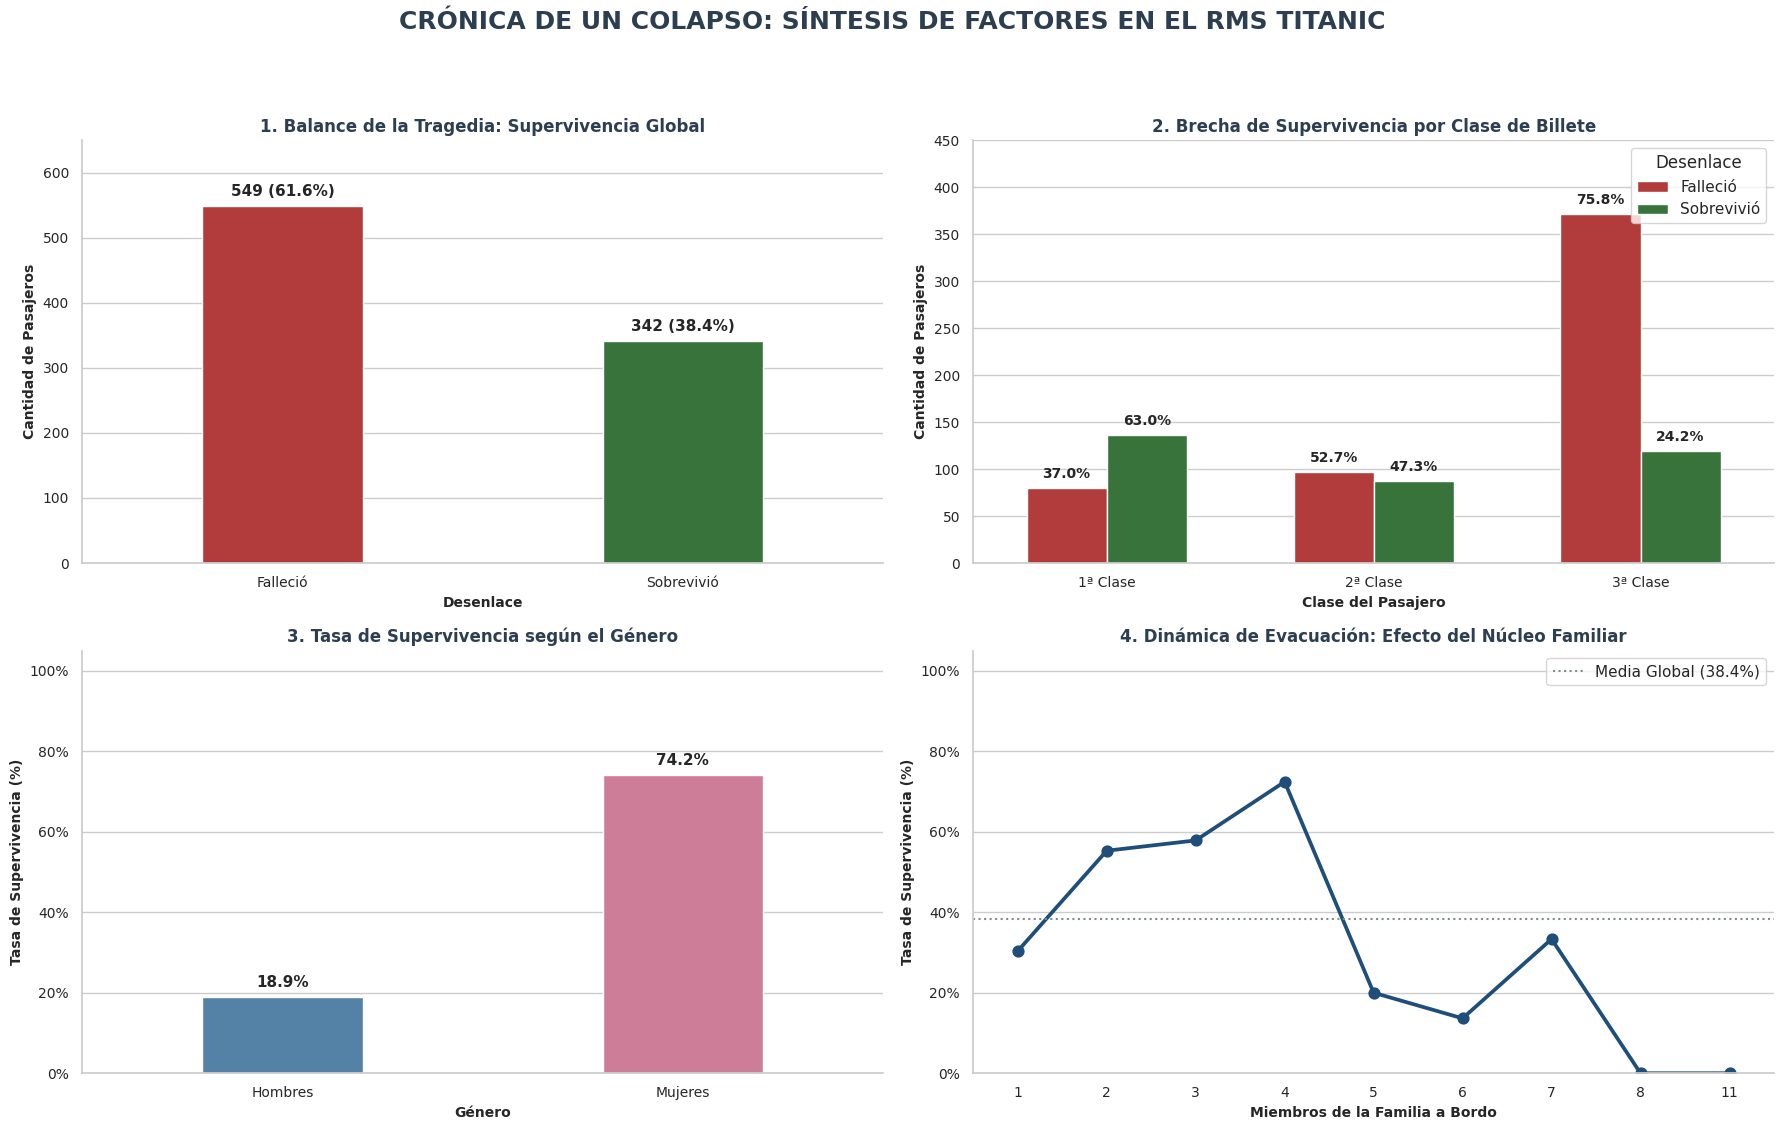

In [48]:


# ==============================================================================
# 1. ENTORNO, DATOS Y PALETA DE COLORES CORPORATIVA
# ==============================================================================
df_dash = df.copy()

# Mapeos semánticos globales para una perfecta legibilidad
df_dash['Estado'] = df_dash['Survived'].map({0: 'Falleció', 1: 'Sobrevivió'})
df_dash['Clase_Nombre'] = df_dash['Pclass'].map({1: '1ª Clase', 2: '2ª Clase', 3: '3ª Clase'})
df_dash['Género'] = df_dash['Sex'].map({'male': 'Hombres', 'female': 'Mujeres'})
df_dash['Tamaño_Familia'] = df_dash['SibSp'] + df_dash['Parch'] + 1

# Colores estandarizados de nuestro portfolio de investigación
PALETA_DASH = {
    'Died': '#c62828', 'Survived': '#2e7d32',
    'Hombres': '#4682b4', 'Mujeres': '#db7093',
    'Dark': '#2c3e50', 'Line': '#1f4e79'
}

# ==============================================================================
# 2. CONFIGURACIÓN DEL LIENZO MAESTRO (MATPLOTLIB SUBPLOTS)
# ==============================================================================
# Creamos una matriz de 2 filas y 2 columnas con dimensiones ejecutivas (18x12 pulgadas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Ajustamos el estilo de fondo global
sns.set_style("white")

# ------------------------------------------------------------------------------
# SUBPLOT 1 (0, 0): BALANCE GENERAL DE LA TRAGEDIA
# ------------------------------------------------------------------------------
ax1 = axes[0, 0]
sns.countplot(data=df_dash, x='Estado', order=['Falleció', 'Sobrevivió'],
              palette=[PALETA_DASH['Died'], PALETA_DASH['Survived']], hue='Estado', legend=False, ax=ax1, width=0.4)

ax1.set_title('1. Balance de la Tragedia: Supervivencia Global', fontsize=12, weight='bold', color=PALETA_DASH['Dark'])
ax1.set_xlabel('Desenlace', fontsize=10, weight='bold')
ax1.set_ylabel('Cantidad de Pasajeros', fontsize=10, weight='bold')
ax1.set_ylim(0, 650)

# Anotaciones numéricas absolutas y porcentuales
for p in ax1.patches:
    h = p.get_height()
    ax1.annotate(f'{int(h)} ({h/len(df_dash)*100:.1f}%)', (p.get_x() + p.get_width()/2., h),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=11, weight='bold')

# ------------------------------------------------------------------------------
# SUBPLOT 2 (0, 1): INFLUENCIA DE LA CLASE SOCIAL
# ------------------------------------------------------------------------------
ax2 = axes[0, 1]
sns.countplot(data=df_dash, x='Clase_Nombre', hue='Estado', order=['1ª Clase', '2ª Clase', '3ª Clase'],
              hue_order=['Falleció', 'Sobrevivió'], palette=[PALETA_DASH['Died'], PALETA_DASH['Survived']], ax=ax2, width=0.6)

ax2.set_title('2. Brecha de Supervivencia por Clase de Billete', fontsize=12, weight='bold', color=PALETA_DASH['Dark'])
ax2.set_xlabel('Clase del Pasajero', fontsize=10, weight='bold')
ax2.set_ylabel('Cantidad de Pasajeros', fontsize=10, weight='bold')
ax2.set_ylim(0, 450)
ax2.legend(title='Desenlace', loc='upper right')

# Anotaciones relativas por clase social interna
totales_clase = df_dash['Clase_Nombre'].value_counts()
for p in ax2.patches:
    h = p.get_height()
    if h == 0 or np.isnan(h): continue
    cx = p.get_x() + p.get_width() / 2.0
    clase_act = '1ª Clase' if cx < 0.5 else ('2ª Clase' if cx < 1.5 else '3ª Clase')
    ax2.annotate(f'{h/totales_clase[clase_act]*100:.1f}%', (p.get_x() + p.get_width()/2., h),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, weight='bold')

# ------------------------------------------------------------------------------
# SUBPLOT 3 (1, 0): EL FACTOR DE GÉNERO
# ------------------------------------------------------------------------------
ax3 = axes[1, 0]
sns.barplot(data=df_dash, x='Género', y='Survived', palette=[PALETA_DASH['Hombres'], PALETA_DASH['Mujeres']],
            hue='Género', legend=False, ax=ax3, width=0.4, errorbar=None)

ax3.set_title('3. Tasa de Supervivencia según el Género', fontsize=12, weight='bold', color=PALETA_DASH['Dark'])
ax3.set_xlabel('Género', fontsize=10, weight='bold')
ax3.set_ylabel('Tasa de Supervivencia (%)', fontsize=10, weight='bold')
ax3.set_ylim(0, 1.05)
ax3.set_yticklabels([f'{int(x*100)}%' for x in ax3.get_yticks()])

for p in ax3.patches:
    h = p.get_height()
    ax3.annotate(f'{h*100:.1f}%', (p.get_x() + p.get_width()/2., h),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=11, weight='bold')

# ------------------------------------------------------------------------------
# SUBPLOT 4 (1, 1): EL IMPACTO DE LA LOGÍSTICA FAMILIAR
# ------------------------------------------------------------------------------
ax4 = axes[1, 1]
sns.pointplot(data=df_dash, x='Tamaño_Familia', y='Survived', color=PALETA_DASH['Line'],
              markers='o', linestyles='-', errorbar=None, ax=ax4)

ax4.set_title('4. Dinámica de Evacuación: Efecto del Núcleo Familiar', fontsize=12, weight='bold', color=PALETA_DASH['Dark'])
ax4.set_xlabel('Miembros de la Familia a Bordo', fontsize=10, weight='bold')
ax4.set_ylabel('Tasa de Supervivencia (%)', fontsize=10, weight='bold')
ax4.set_ylim(0, 1.05)
ax4.set_yticklabels([f'{int(x*100)}%' for x in ax4.get_yticks()])

# Línea base de control (Media general del navío)
ax4.axhline(0.3838, color='#7f8c8d', linestyle=':', linewidth=1.5, label='Media Global (38.4%)')
ax4.legend(loc='upper right')

# ==============================================================================
# 3. TITULACIÓN GENERAL Y LIMPIEZA VISUAL (ESTILO DATA-INK RATIO)
# ==============================================================================
plt.suptitle('CRÓNICA DE UN COLAPSO: SÍNTESIS DE FACTORES EN EL RMS TITANIC',
             fontsize=18, weight='bold', color=PALETA_DASH['Dark'], y=0.97)

# Bucle optimizado para remover bordes innecesarios en todas las subtramas simultáneamente
for ax in axes.flat:
    sns.despine(ax=ax)

# Ajuste milimétrico de espaciados para evitar solapamientos de textos
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Renderizar Dashboard
plt.show()


## 3. Explicación Narrativa de la Historia

**La Historia de los Datos:** El colapso del Titanic no afectó a todos por igual. Inicialmente descubrimos que la gran mayoría de la población a bordo falleció (**61.6%**). Sin embargo, al desglosar esa realidad, observamos que el dinero compraba vida: mientras que en Primera Clase sobrevivió la gran mayoría (**63.0%**), en Tercera Clase murieron tres de cada cuatro pasajeros (**75.8%**).

Paralelamente, las normas sociales protegieron masivamente a las mujeres, dándoles un **74.2%** de probabilidades de salvarse frente a un bajísimo **18.9%** para los hombres.

Finalmente, la logística familiar dictó la última palabra: viajar solo disminuía las oportunidades de alerta mutua (**30.4%** de éxito), pero viajar en familias gigantescas colapsaba la capacidad de abordar un bote juntos, marcando a las **familias pequeñas (de 2 a 4 personas)** como el grupo más resiliente de la noche.


## Reflexión Final
Para cerrar tu documento de investigación con broche de oro, aquí tienes las respuestas metodológicas a las preguntas planteadas en la guía:

### 1. ¿Qué gráfico te resultó más difícil de elegir? ¿Por qué?

El gráfico para la relación entre la **Edad y la Supervivencia** (*Pregunta 10*) representó el mayor desafío analítico. Al cruzar una variable continua con una binaria, la tentación inicial es usar un *Boxplot* o un *Scatterplot*.

Sin embargo, el *Boxplot* solo describe medidas de centro estáticas perdiendo el detalle de los extremos (los niños), y el *Scatterplot* provoca una saturación ilegible por puntos encimados (*overplotting*). La elección de un **Gráfico de Densidad de Kernel (KDE Plot) superpuesto y normalizado** fue la única opción metodológica capaz de aislar visualmente el comportamiento bimodal no lineal del rescate infantil.

### 2. ¿Hubo alguna pregunta donde varios tipos de gráfico eran igualmente válidos? ¿Cuál elegiste al final y por qué?

En la *Pregunta 1* (Composición de clases), tanto el gráfico de barras (`countplot`) como el gráfico de sectores o tarta (*pie chart*) eran metodológicamente válidos para reflejar proporciones.

Se optó definitivamente por el **gráfico de barras complementado con anotaciones de porcentaje**. La decisión responde al principio de la psicología cognitiva de que el cerebro humano procesa con mayor velocidad y precisión milimétrica la diferencia de longitudes sobre un eje común alineado que el área superficial o la apertura angular de sectores circulares fracturados.

### 3. ¿Qué hallazgo de los datos te sorprendió más?

Desde una perspectiva puramente estadística, el comportamiento en forma de **parábola invertida** del tamaño de la estructura familiar sobre la tasa de supervivencia.

Resulta fascinante descubrir cómo un factor puramente social e íntimo altera de forma matemática las probabilidades de vida: la existencia de un **"punto dulce" de eficiencia en grupos de 3 a 4 personas**, acorralado por las penalizaciones de supervivencia de los individuos aislados por un lado, y el colapso logístico/emocional absoluto de las familias numerosas por el otro.

